# Análisis de los nuevos datos

In [1]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit

Este Notebook consiste en evaluar la distribución de las variables para los nuevos datos (correspondientes al año 2026 hasta abril).

Con él se pretende observar la comparativa con respecto a los datos que teníamos en la fase anterior.

### **Características de las variables**

In [12]:
df_2026 = mf.bajar_fichero(mf.crear_cliente(), "grupo3/cleaned/final_cleaned_2026.parquet", "df")

Dataframe final_cleaned_2026.parquet importado correctamente


In [13]:
df_hasta_2025 = mf.bajar_fichero(mf.crear_cliente(), "grupo3/cleaned/MINI.parquet", "df")

Dataframe MINI.parquet importado correctamente


**COMPOSICIÓN DEL DATASET**

Total de filas y proporción de incendios y no incendios:

In [14]:
total = len(df_2026)
total_incendios = len(df_2026[df_2026['final'] == 1])
total_no_incendios = len(df_2026[df_2026['final'] == 0])
print(f"La longitud total de los datos es de: {total}")
print(f"Proporción de incendios: {np.round(total_incendios * 100 / total, 2)} %")
print(f"Proporción de no incendios: {np.round(total_no_incendios * 100 / total, 2)} %")

La longitud total de los datos es de: 550
Proporción de incendios: 4.0 %
Proporción de no incendios: 96.0 %


Se observa que la proporción de incendios ha subido con respecto al dataset que teníamos para la fase anterior.

**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

In [15]:
df = df_2026.drop(columns = ['final', 'date', 'lat', 'lon']) 
df.describe()

,elevacion_centro,grados,porcentaje,temp_max,temp_min,precipitation,wind_speed_max,wind_gusts_max,radiation,evapotranspiration,...,temp_mean,humidity_mean,pressure_mean,cloud_cover,soil_temp,dist_civ,NDVI,NDWI,dia_sin,dia_cos
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.0000,550.000000,550.000000,550.000000,...,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000
mean,414.105648,6.119684,11.161084,9.501818,0.580182,2.657455,17.6600,37.196727,11.572964,1.898018,...,4.850727,72.398485,966.690606,63.310076,5.247945,83.915887,0.299102,-0.335068,0.741411,0.377631
std,438.190289,8.360732,15.774712,8.489458,6.777714,6.051660,7.5803,15.317725,6.830480,1.607608,...,7.293245,17.004600,50.363055,33.312869,6.052758,223.851565,0.263240,0.260926,0.297922,0.468516
min,-0.807681,0.000475,0.000830,-23.200000,-32.900000,0.000000,5.2000,12.600000,0.740000,0.070000,...,-29.800000,10.000000,797.800000,0.000000,-11.100000,0.167158,-0.710526,-0.856564,0.103102,-0.381689
25%,107.020847,0.420483,0.733895,4.700000,-2.175000,0.000000,12.1000,26.300000,4.850000,0.572500,...,1.700000,60.000000,938.100000,36.000000,0.750000,5.068651,0.100178,-0.540145,0.594727,-0.150055
50%,218.704582,1.721431,3.005368,10.800000,0.750000,0.100000,16.2000,34.600000,12.550000,1.775000,...,5.300000,75.000000,987.550000,72.354167,4.780000,8.838362,0.256179,-0.355206,0.924291,0.373720
75%,669.732285,8.570193,15.070370,14.900000,4.400000,2.525000,21.3000,43.200000,16.782500,2.665000,...,8.900000,85.000000,1001.906250,94.000000,8.100000,14.799730,0.494600,-0.164684,0.985948,0.803928
max,2042.936401,39.394308,82.124291,32.100000,20.900000,53.800000,44.2000,113.400000,27.880000,10.600000,...,25.600000,99.000000,1034.800000,100.000000,26.230000,1172.087990,0.875420,0.897674,0.994218,0.994671


**DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS**

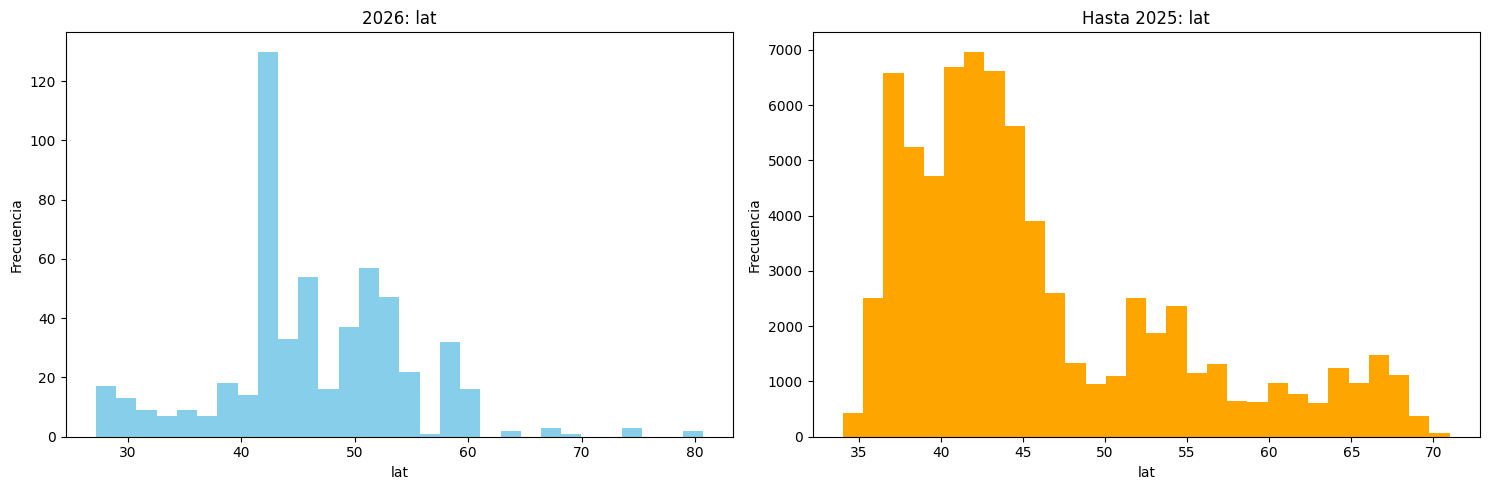

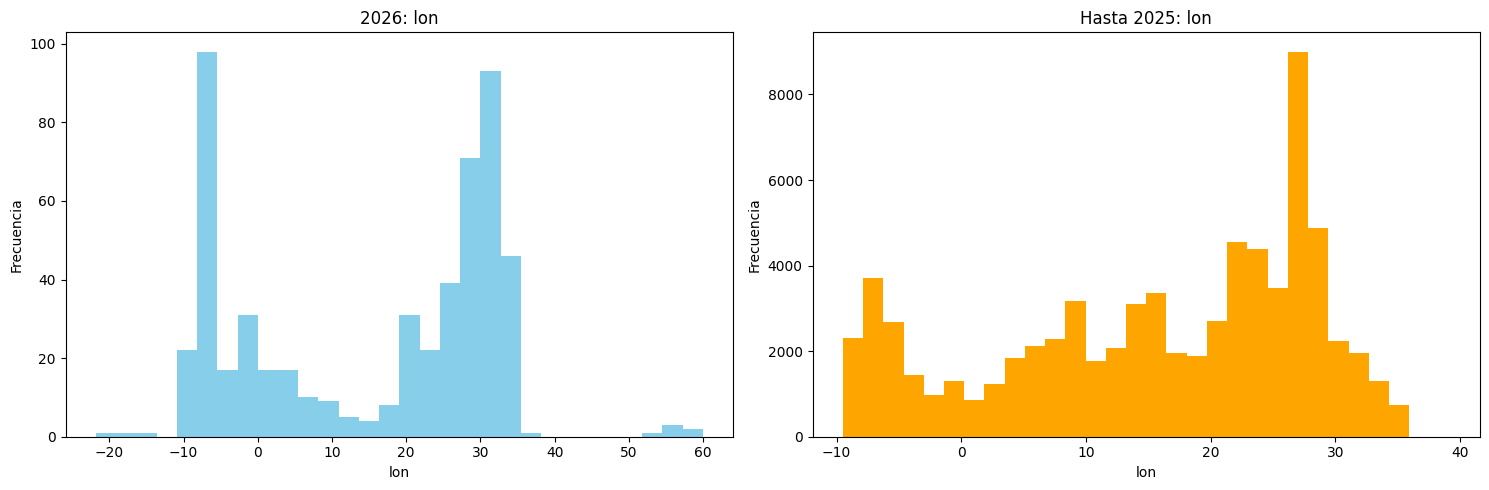

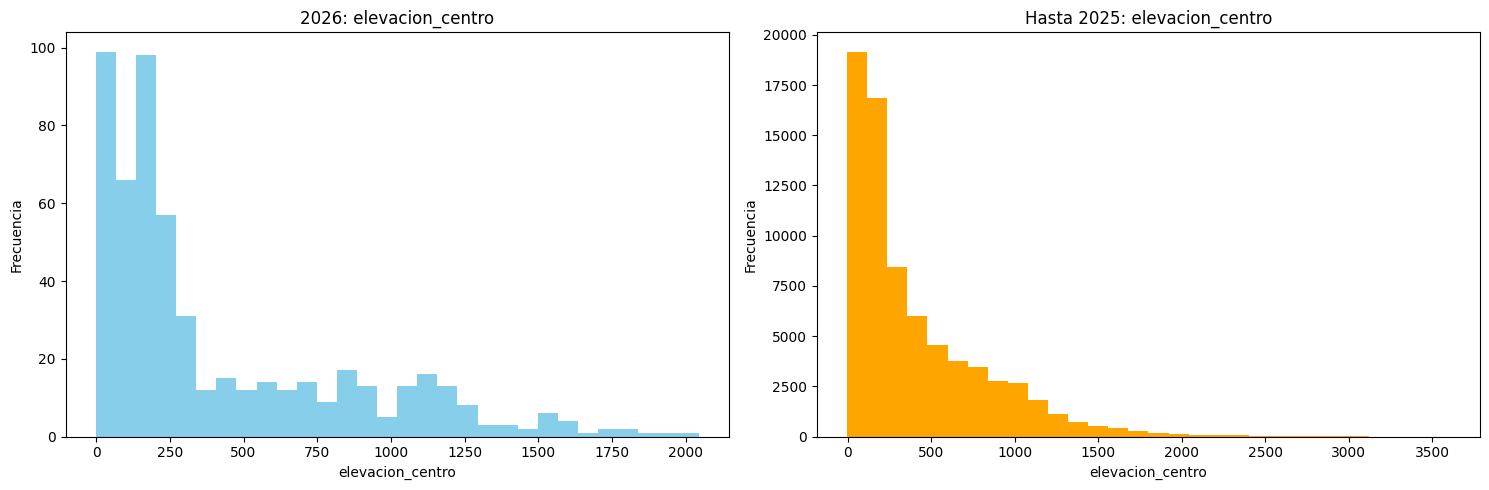

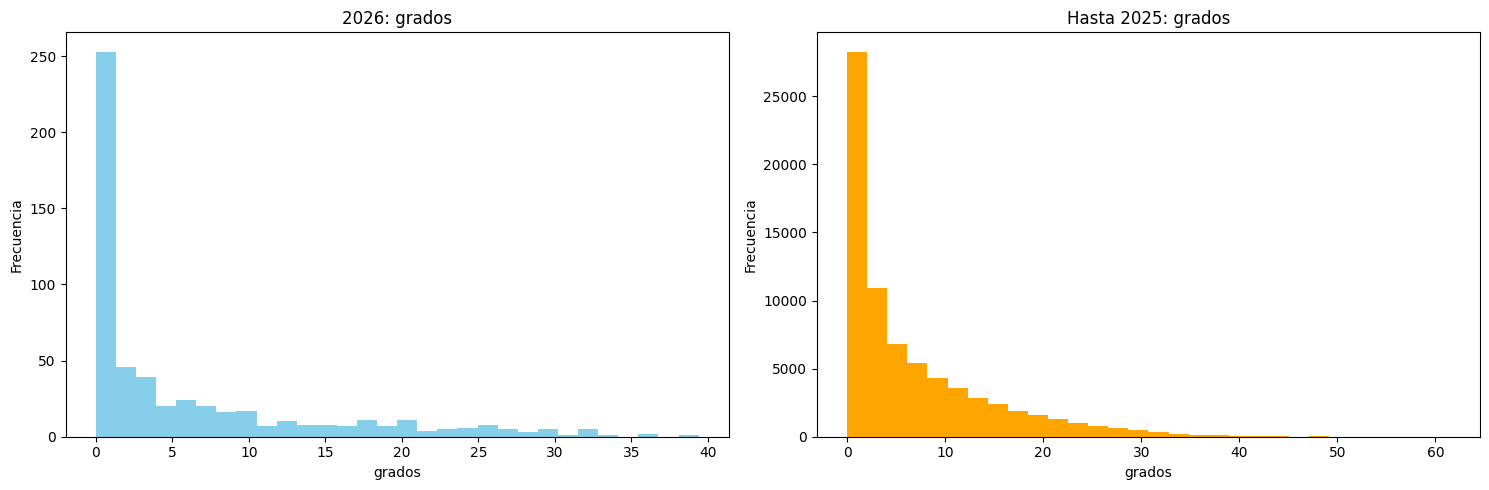

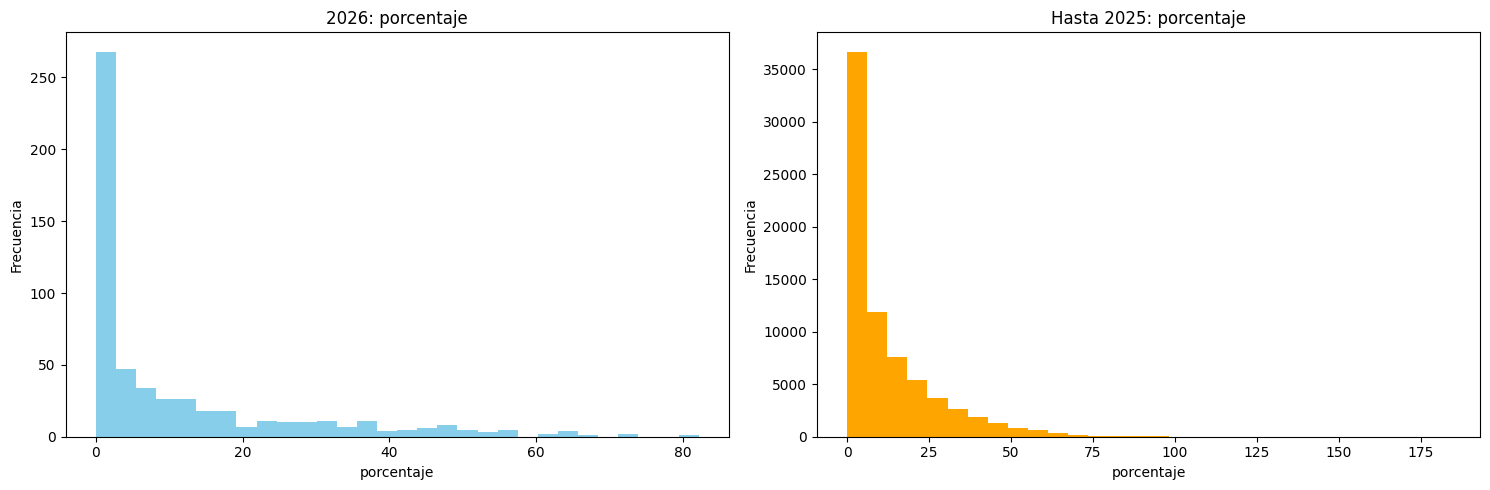

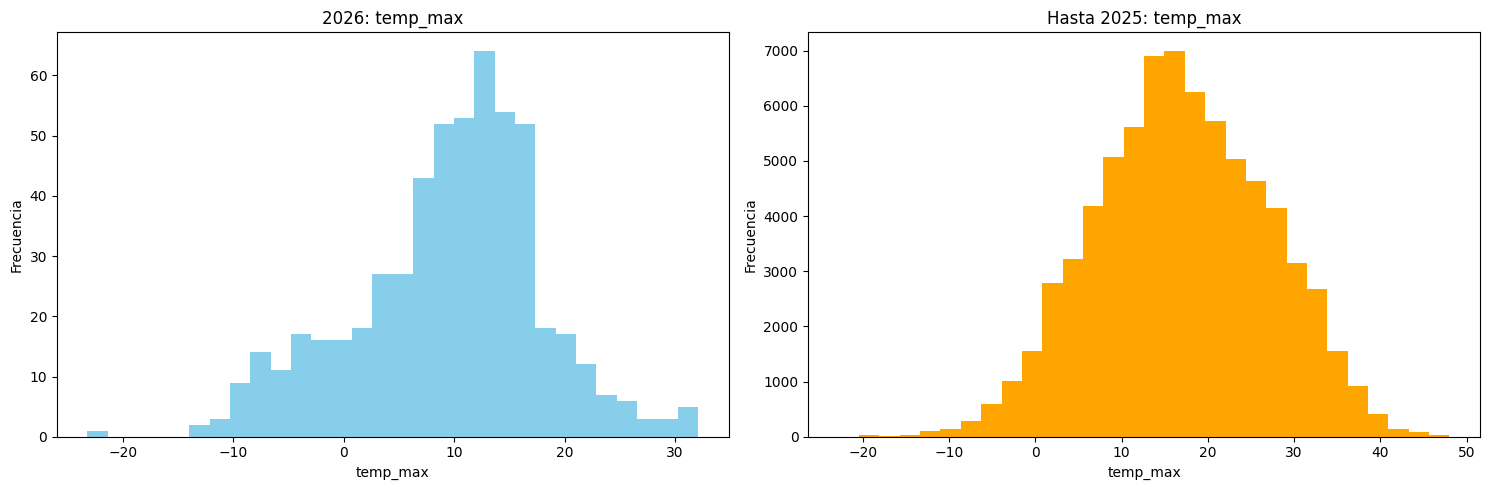

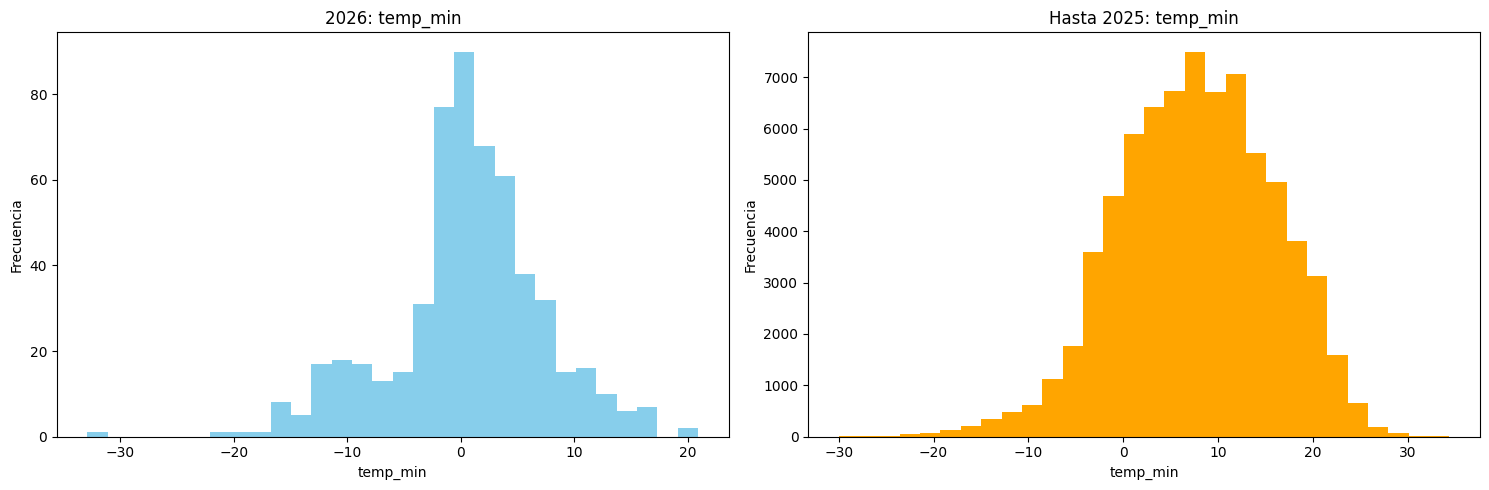

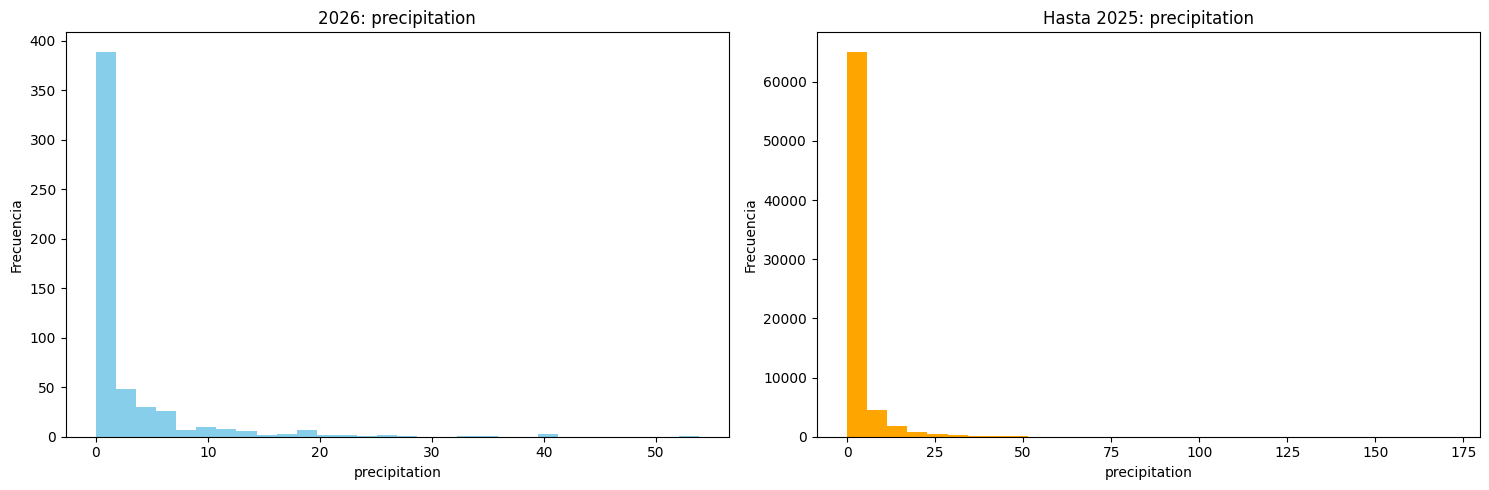

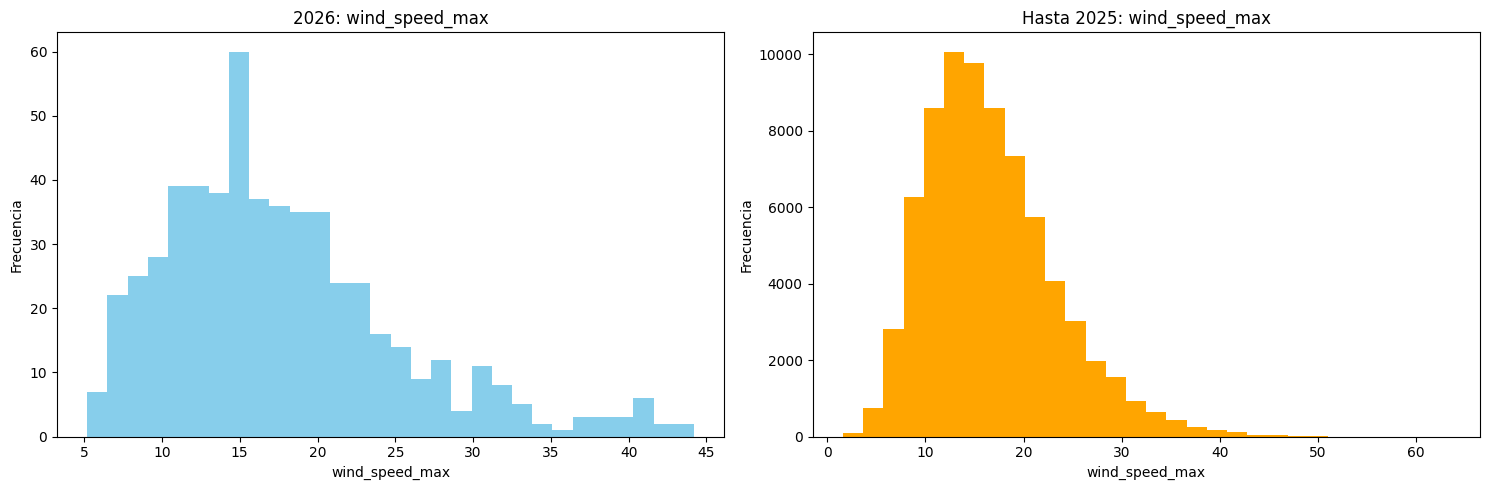

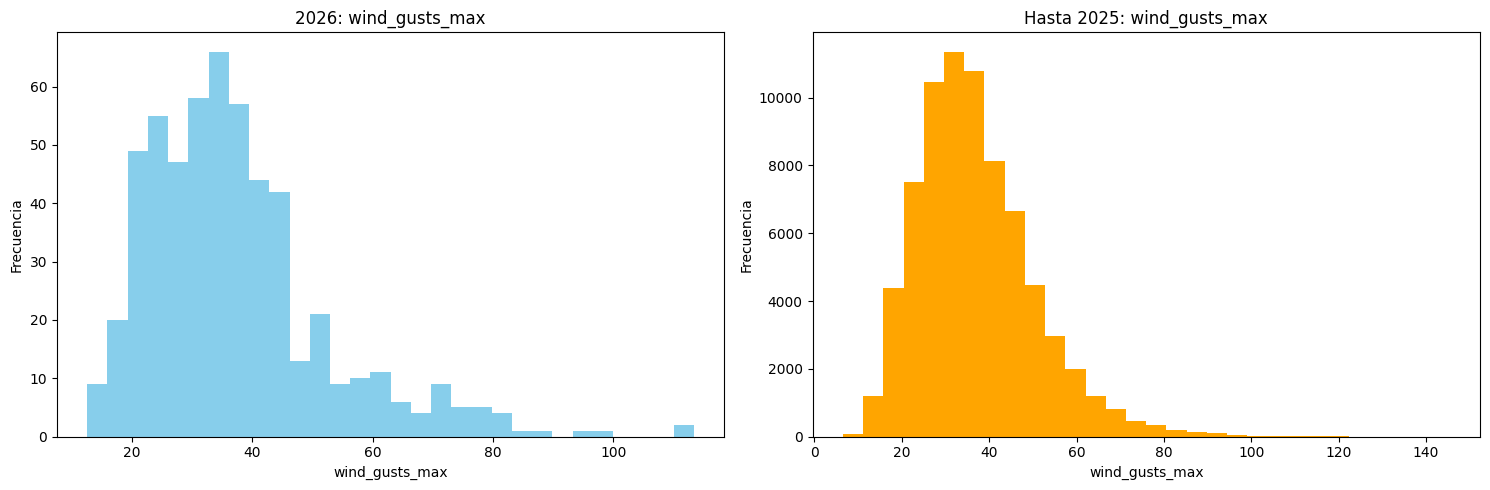

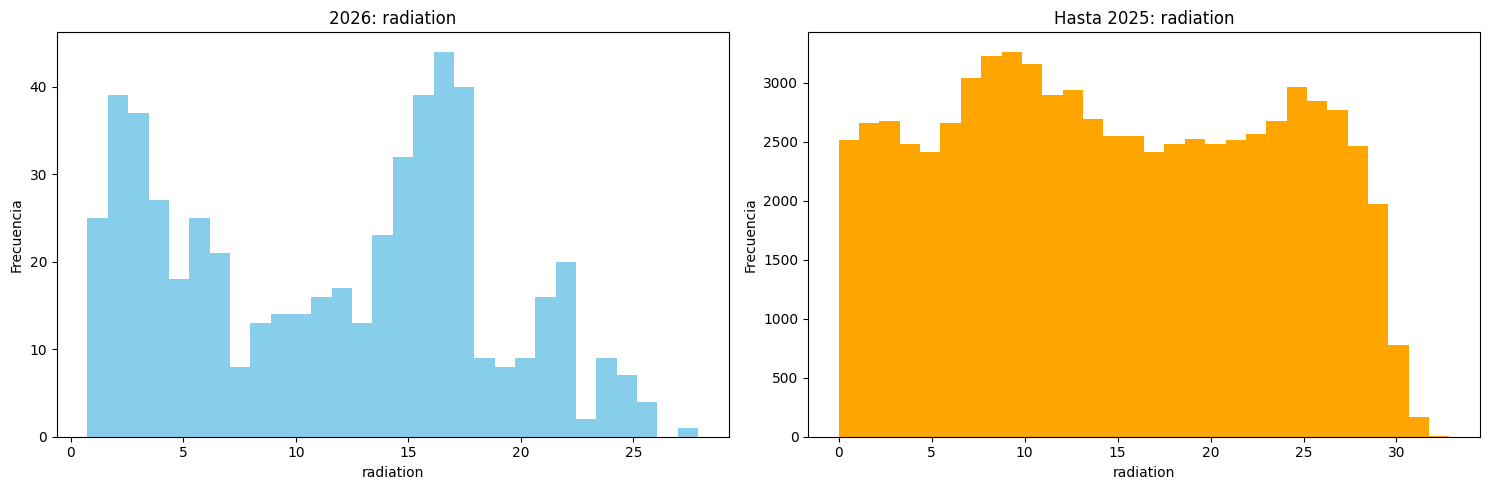

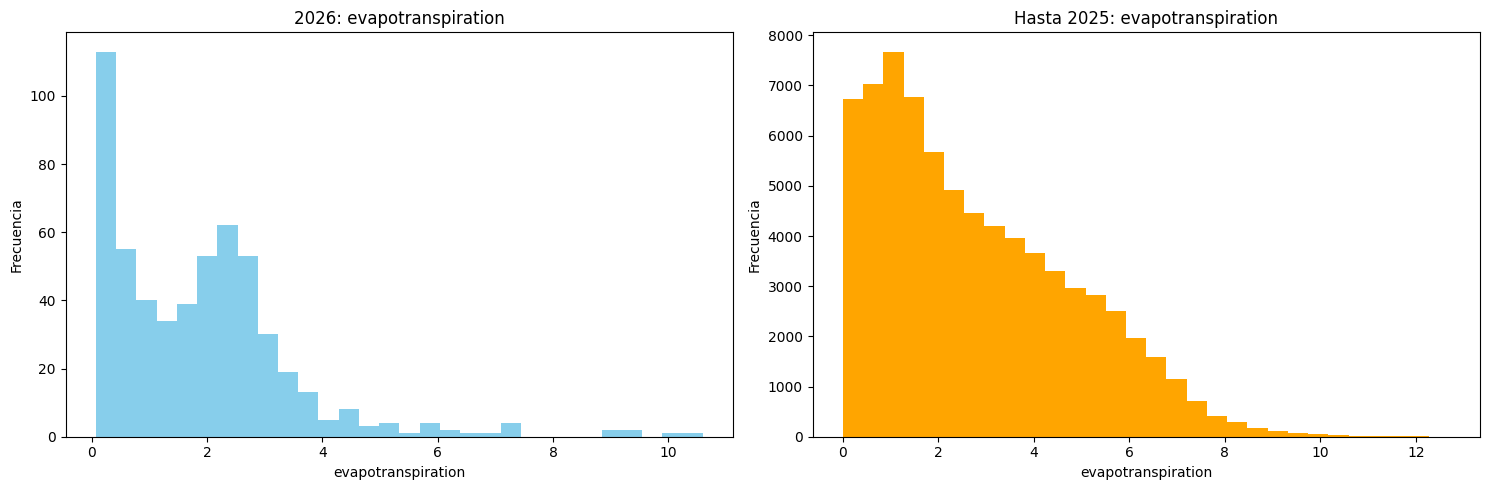

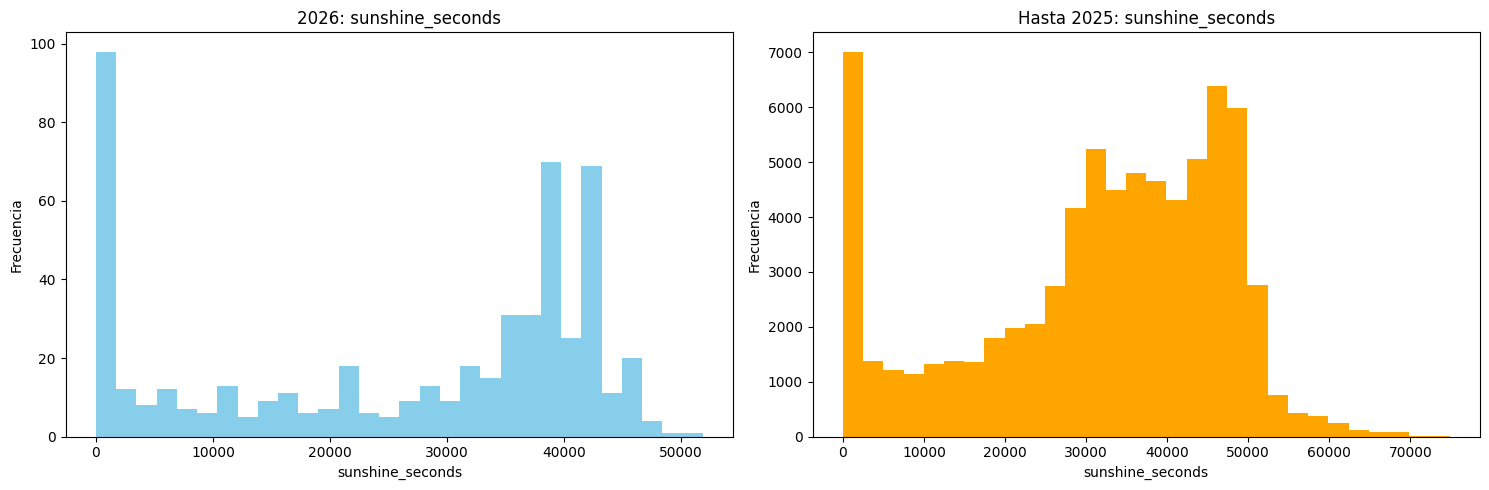

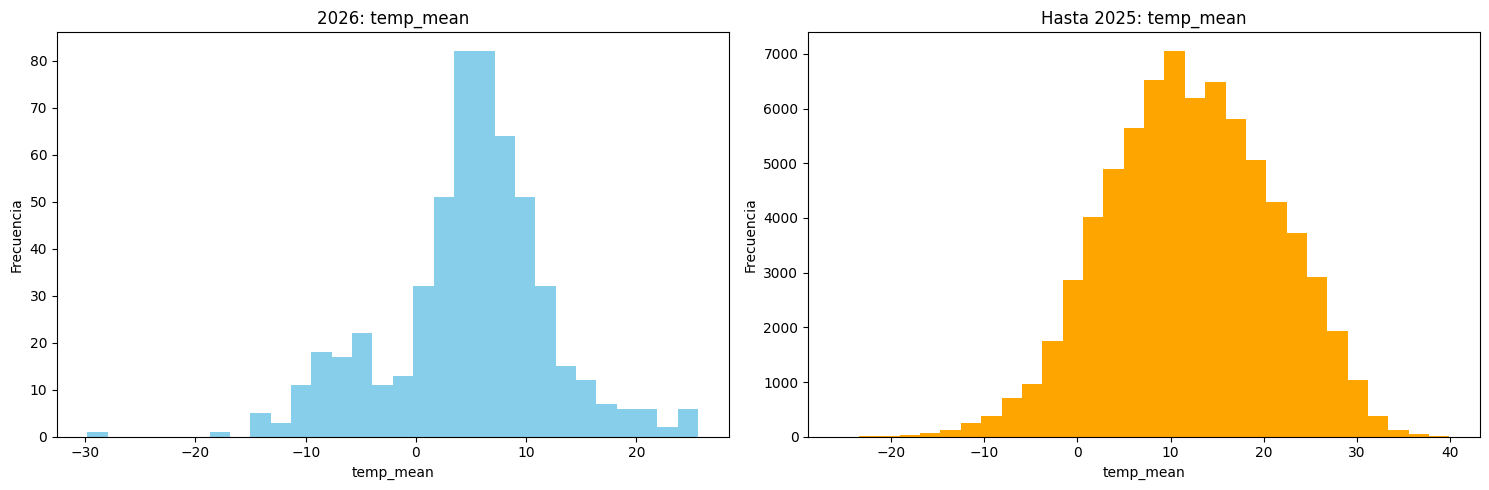

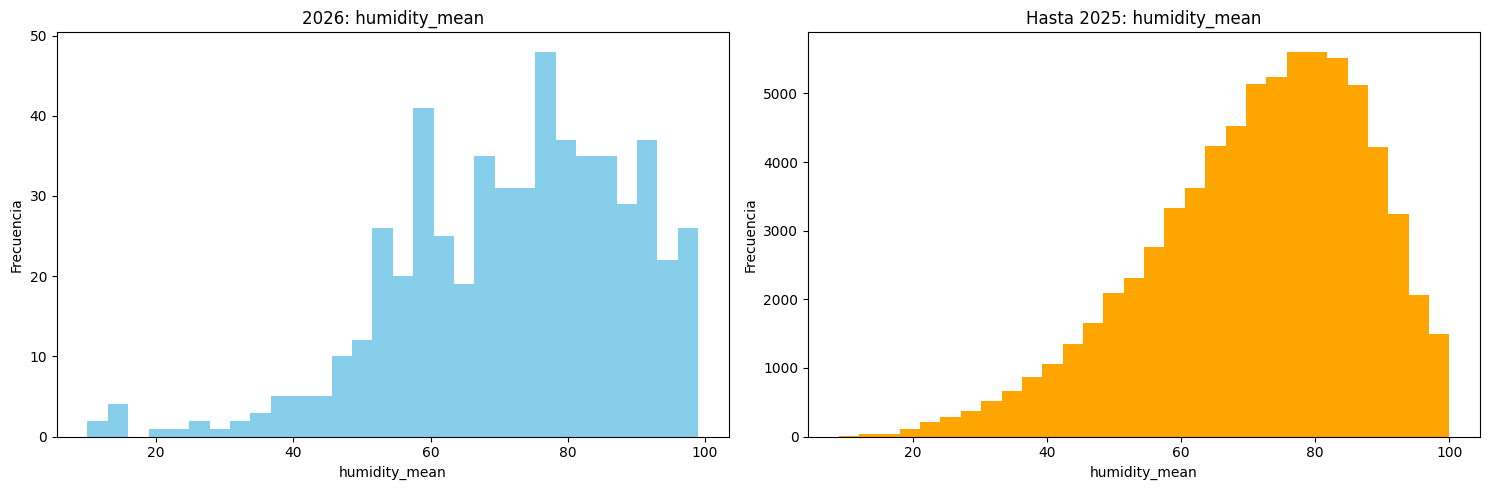

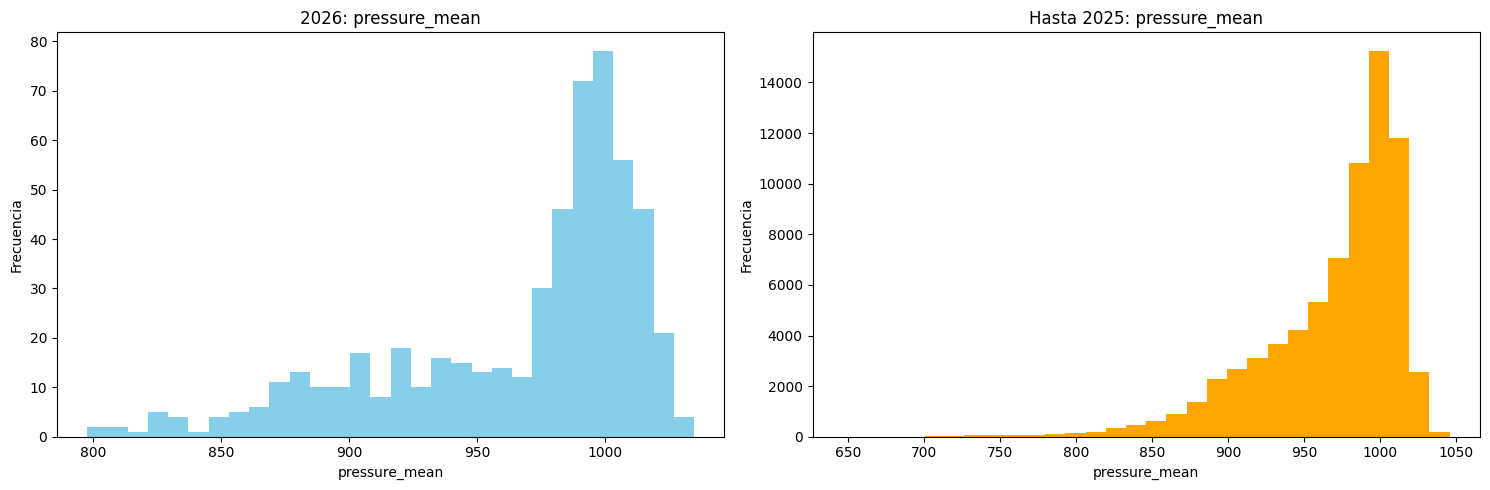

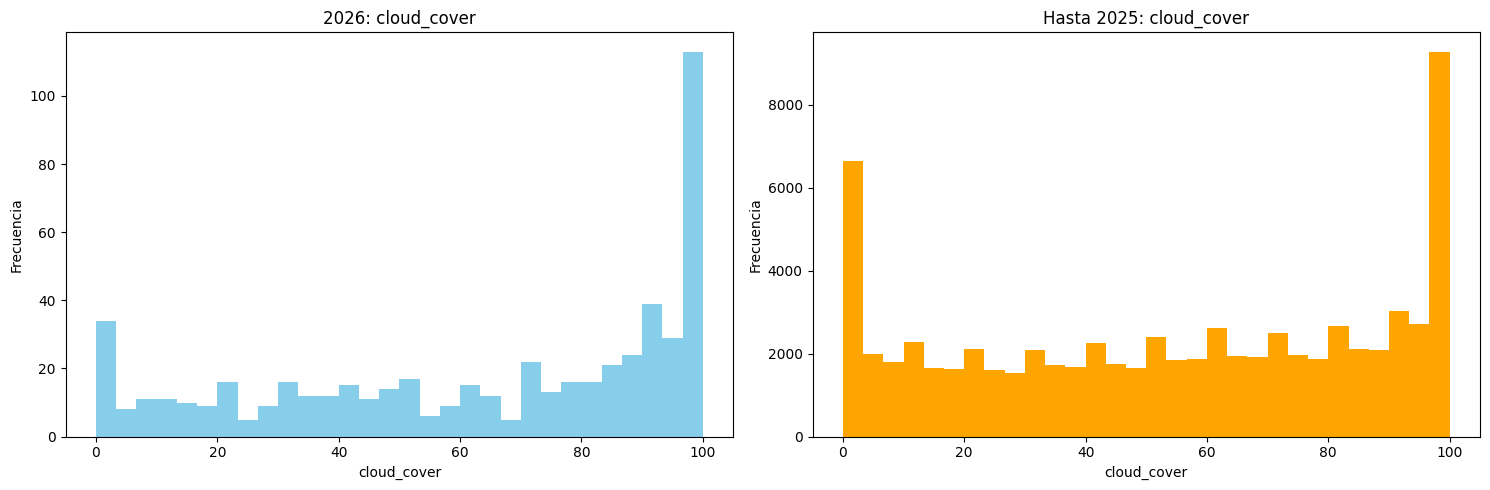

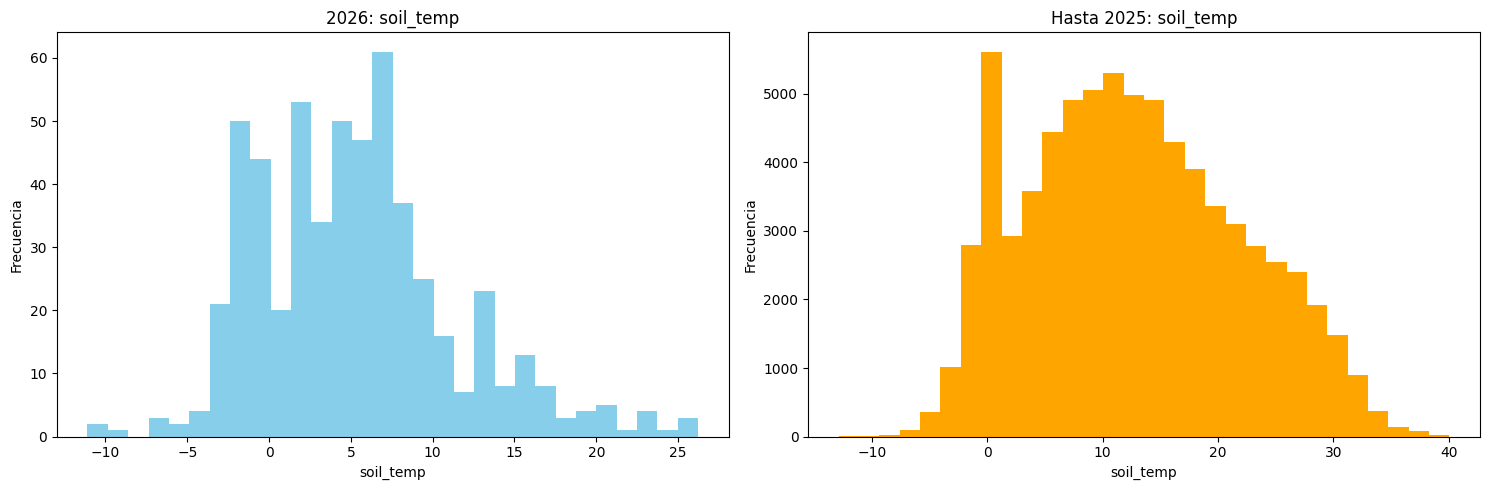

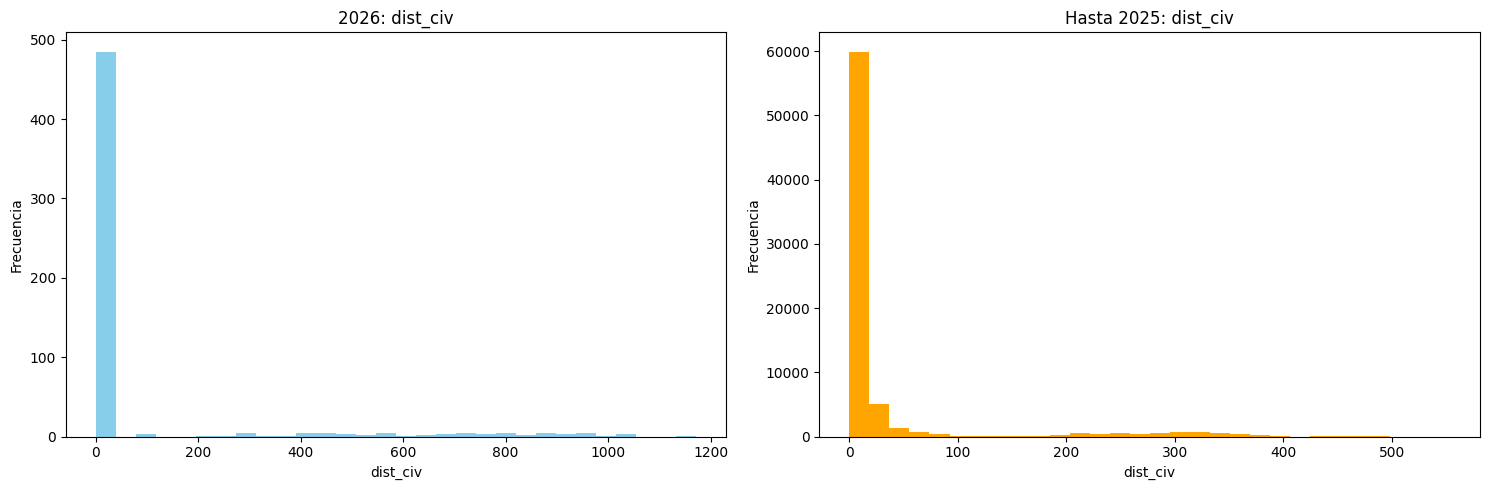

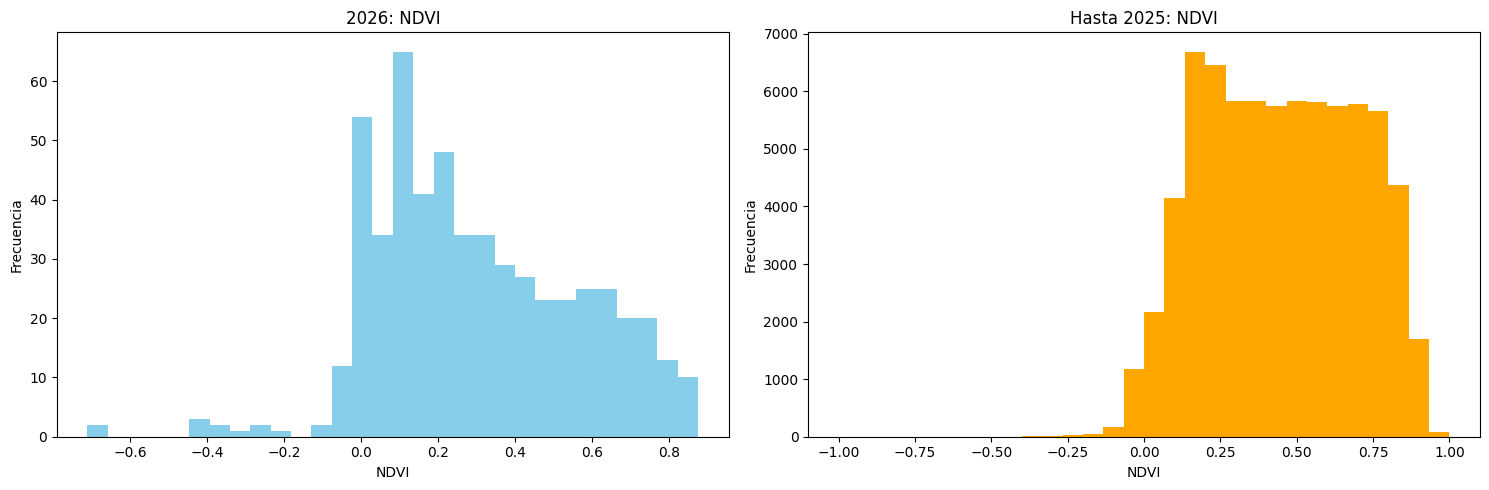

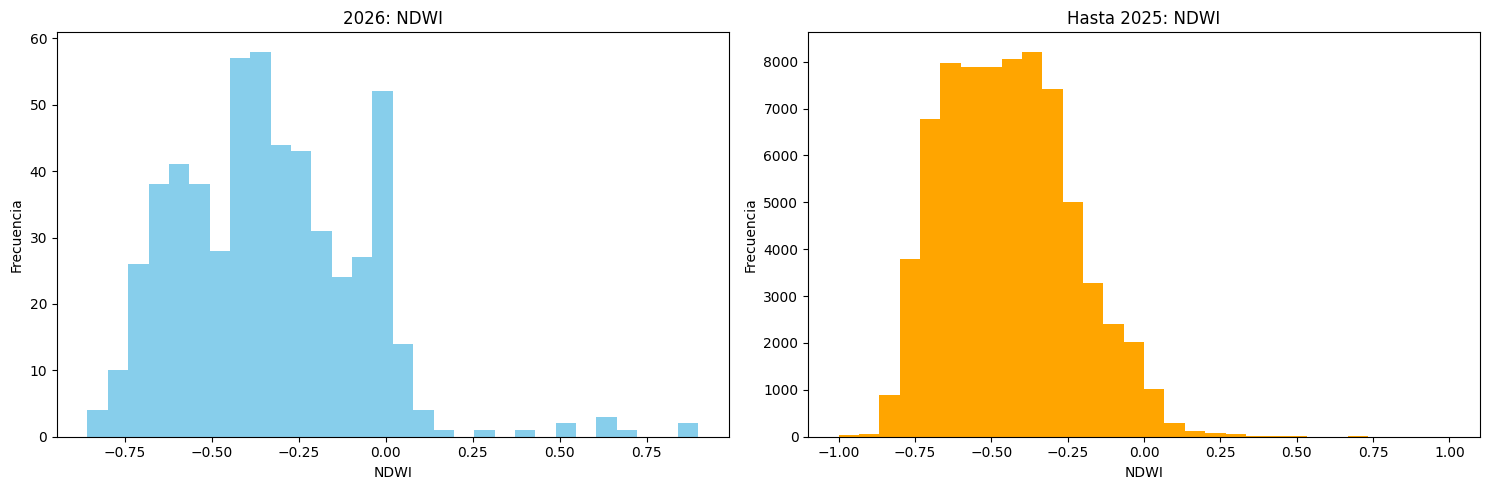

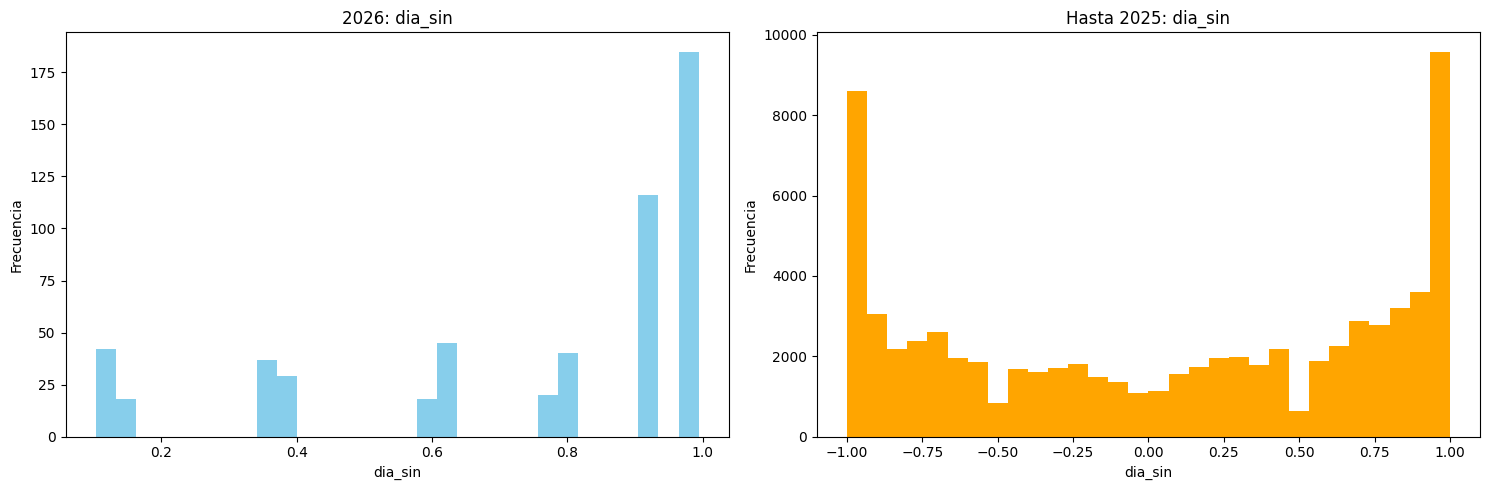

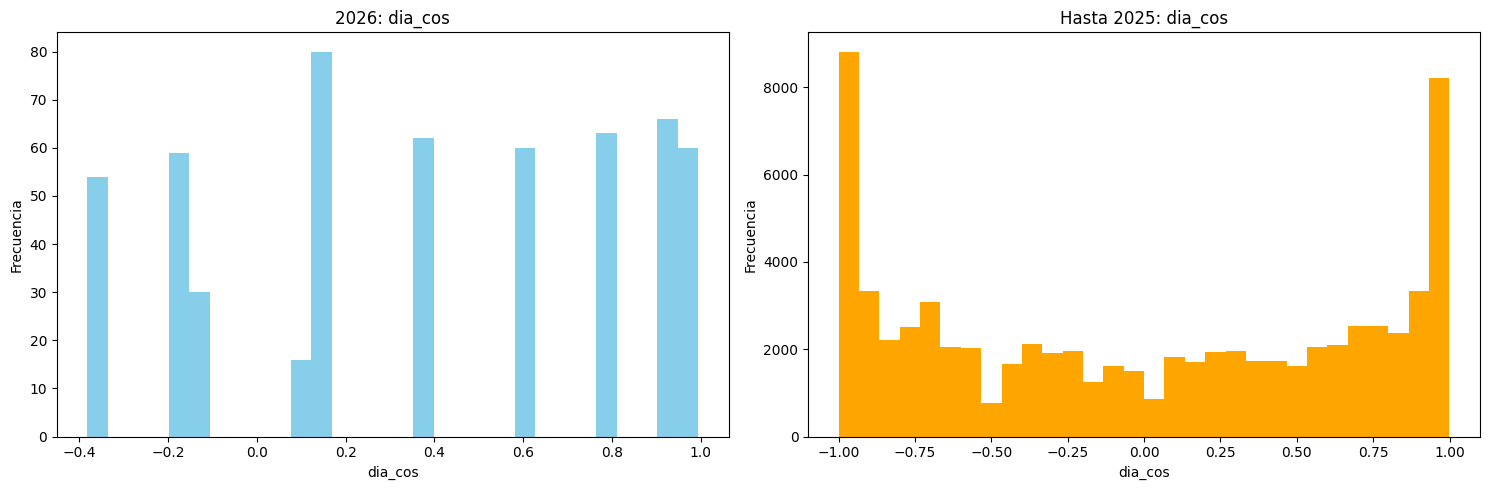

In [33]:
columnas = df_2026.columns.drop(["date", "final"])

for col in columnas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfica de 2026 (Izquierda)
    df_2026[col].hist(bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title(f'2026: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(False)

    # Gráfica hasta 2025 (Derecha)
    df_hasta_2025[col].hist(bins=30, ax=axes[1], color='orange')
    axes[1].set_title(f'Hasta 2025: {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frecuencia')
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

Ahora vamos a evaluar las diferencias únicamente para los datos de incendio:

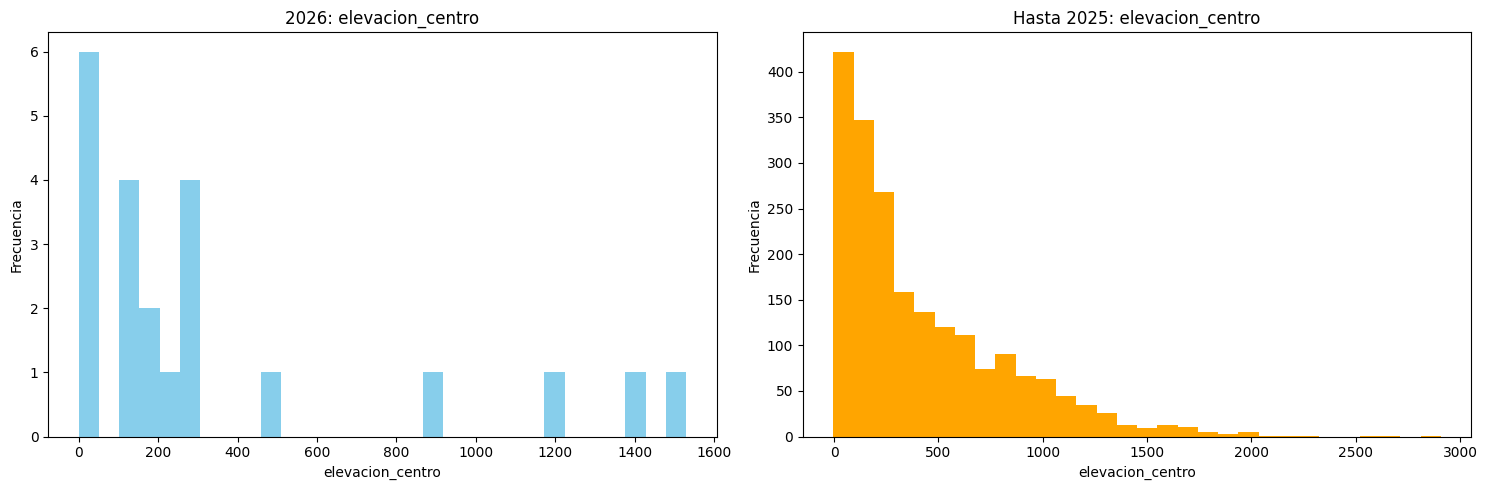

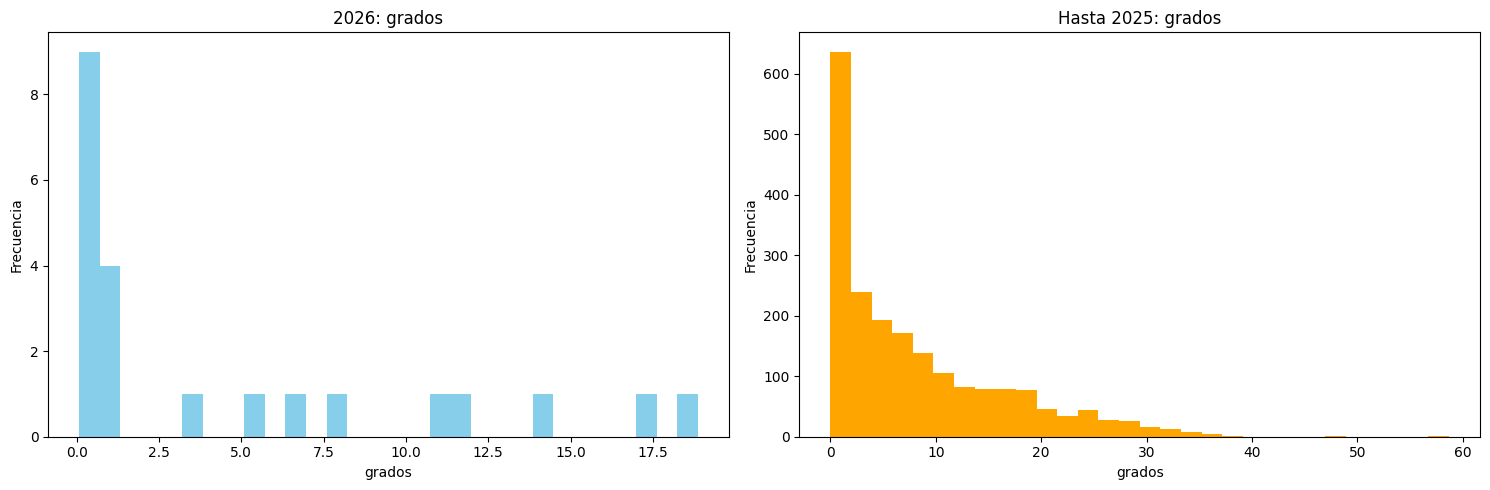

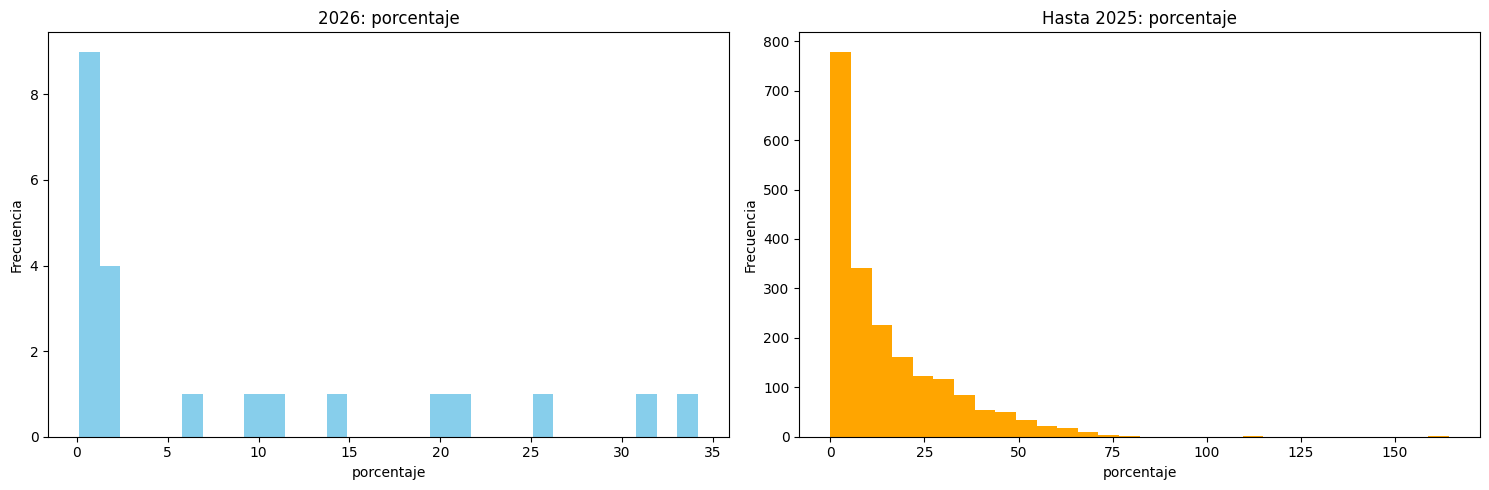

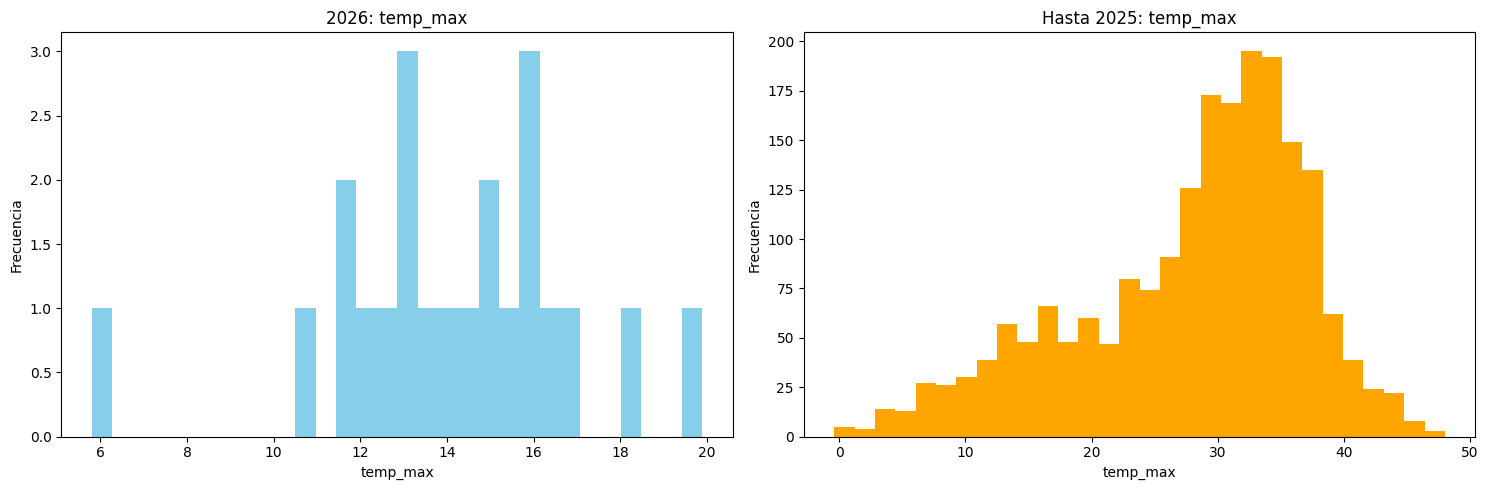

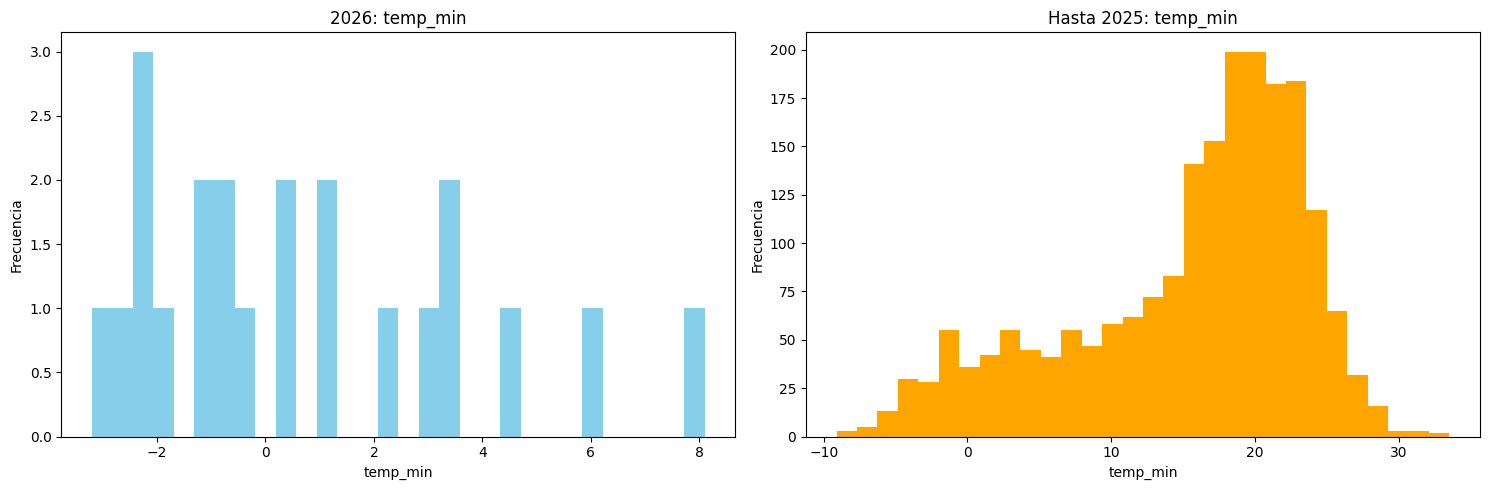

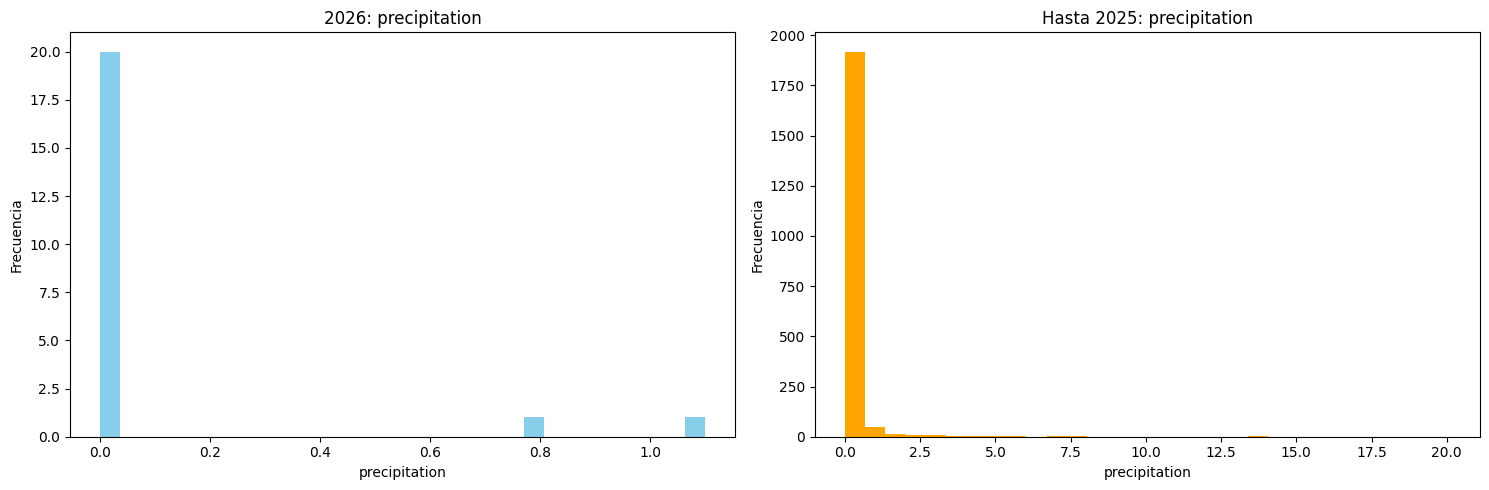

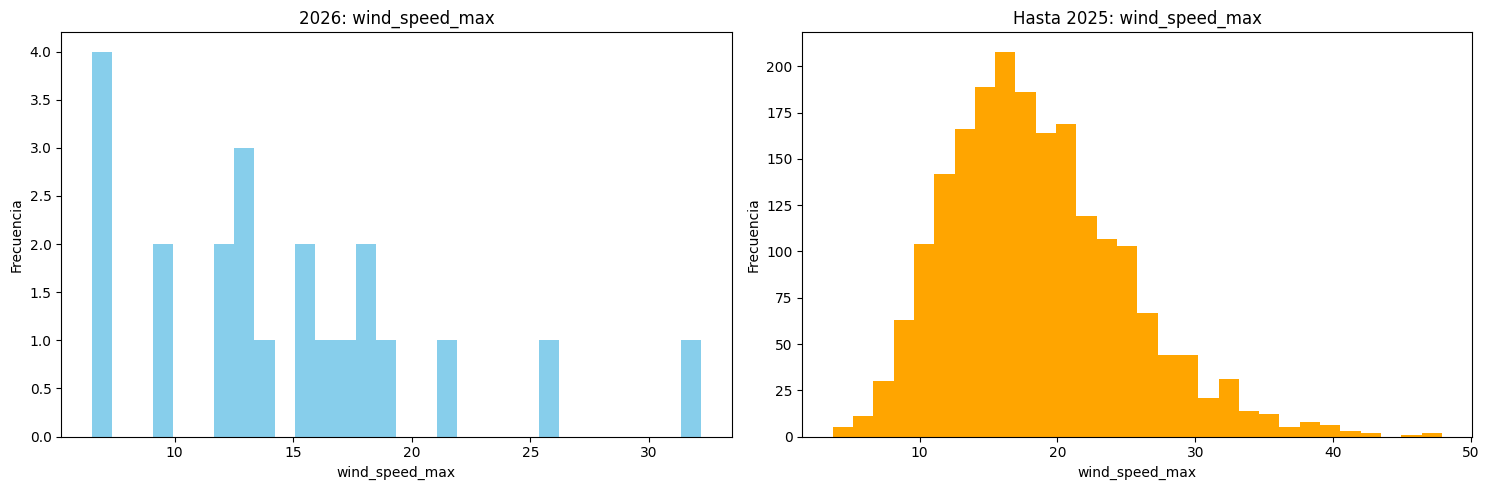

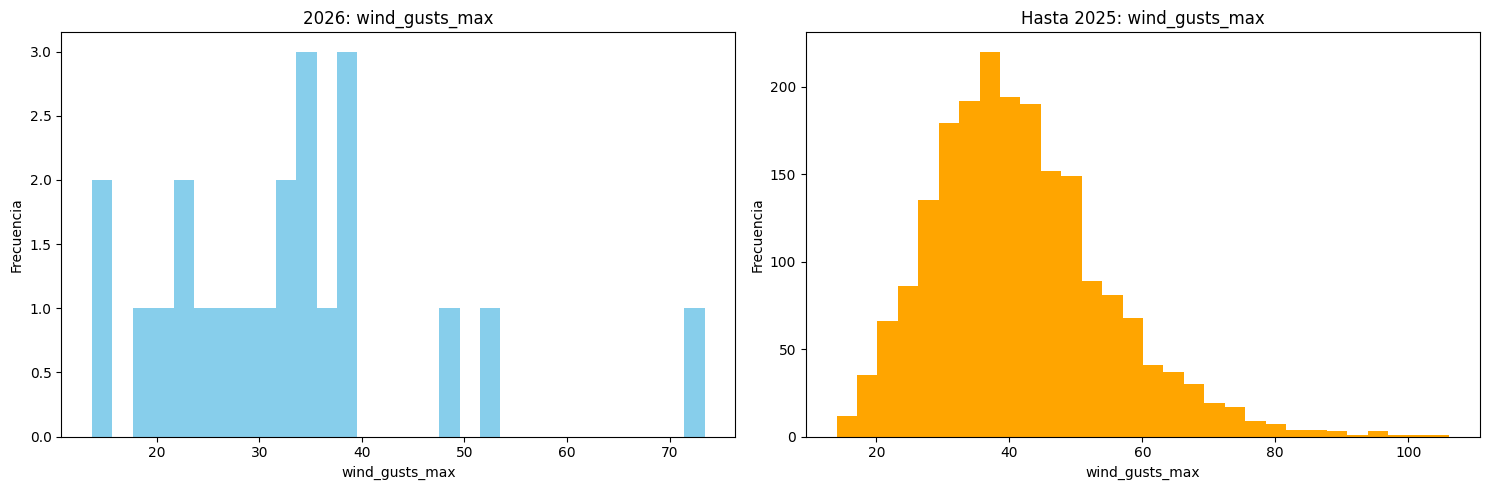

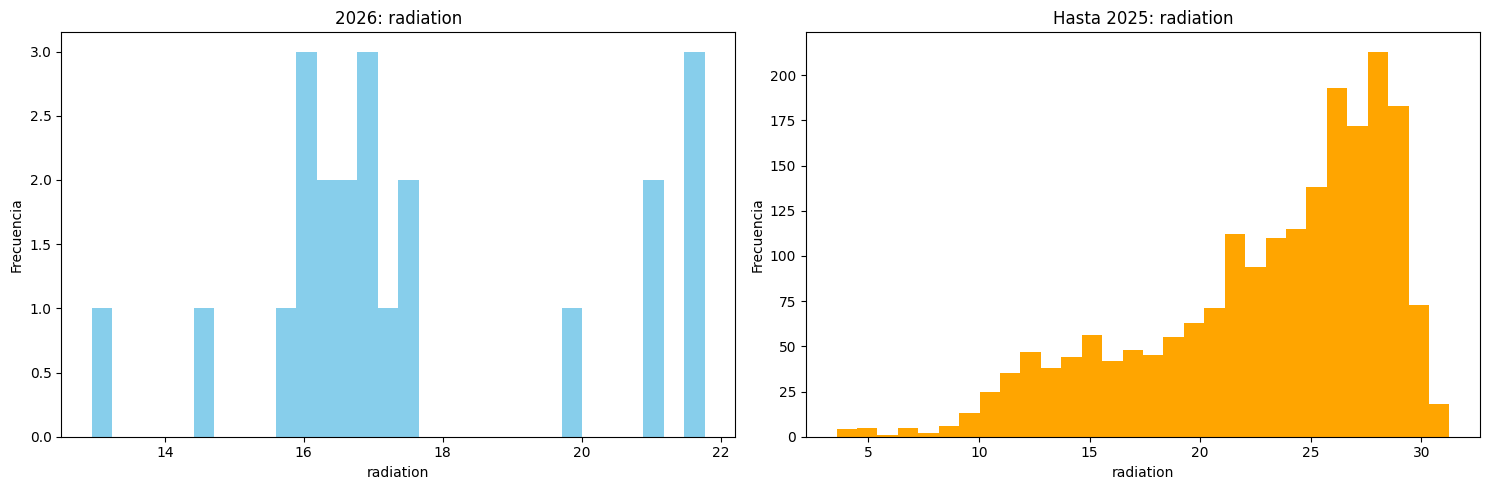

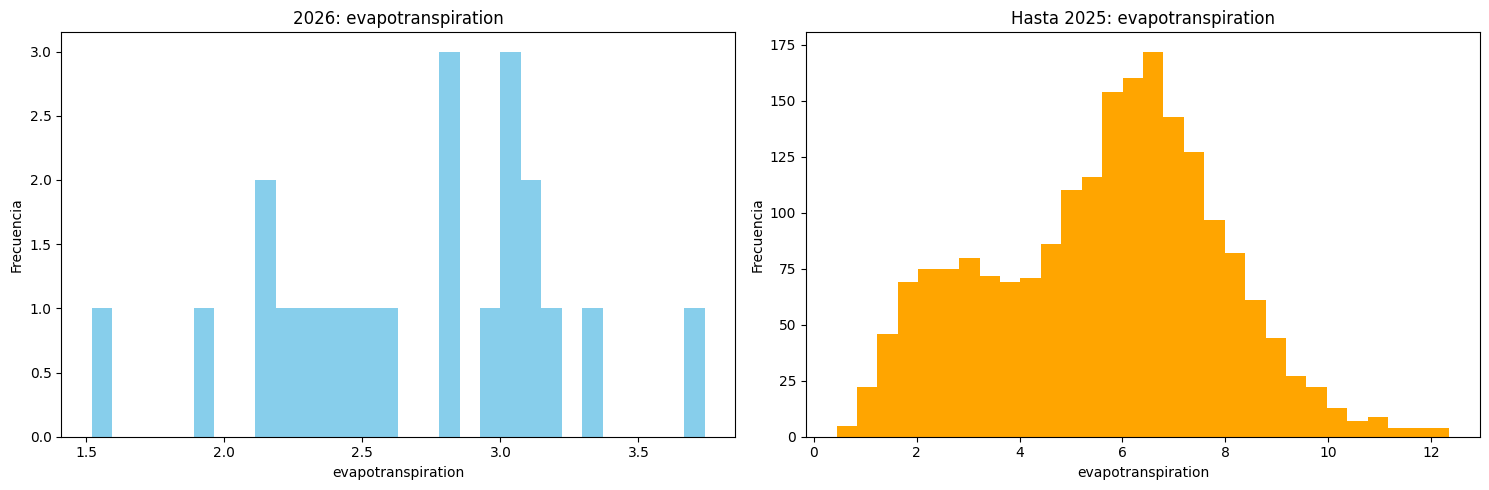

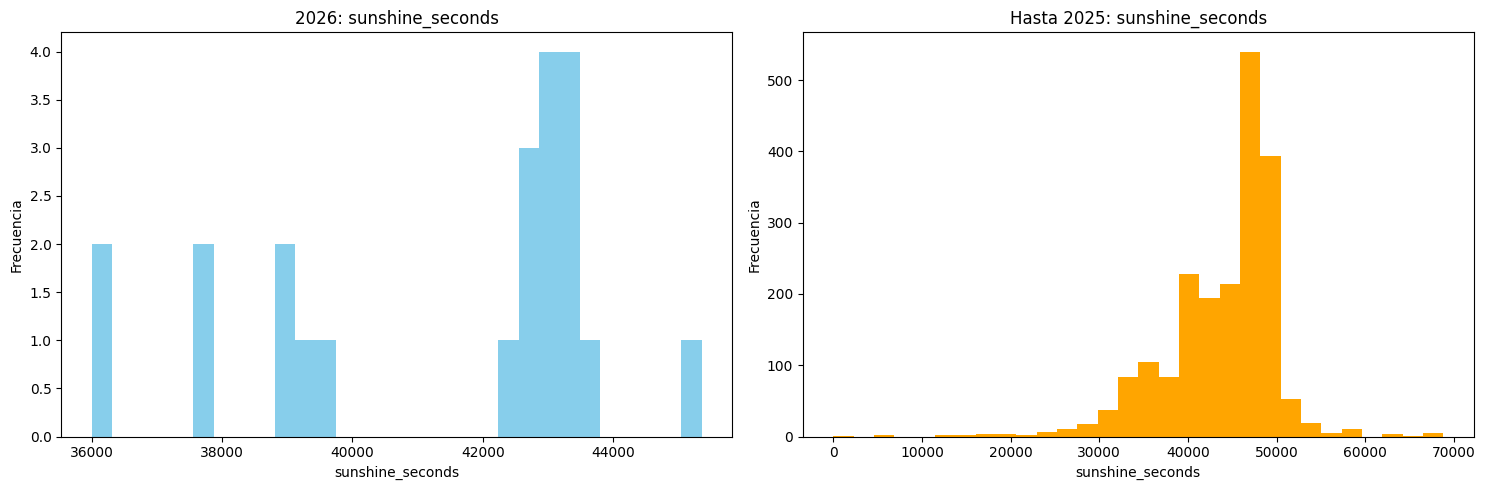

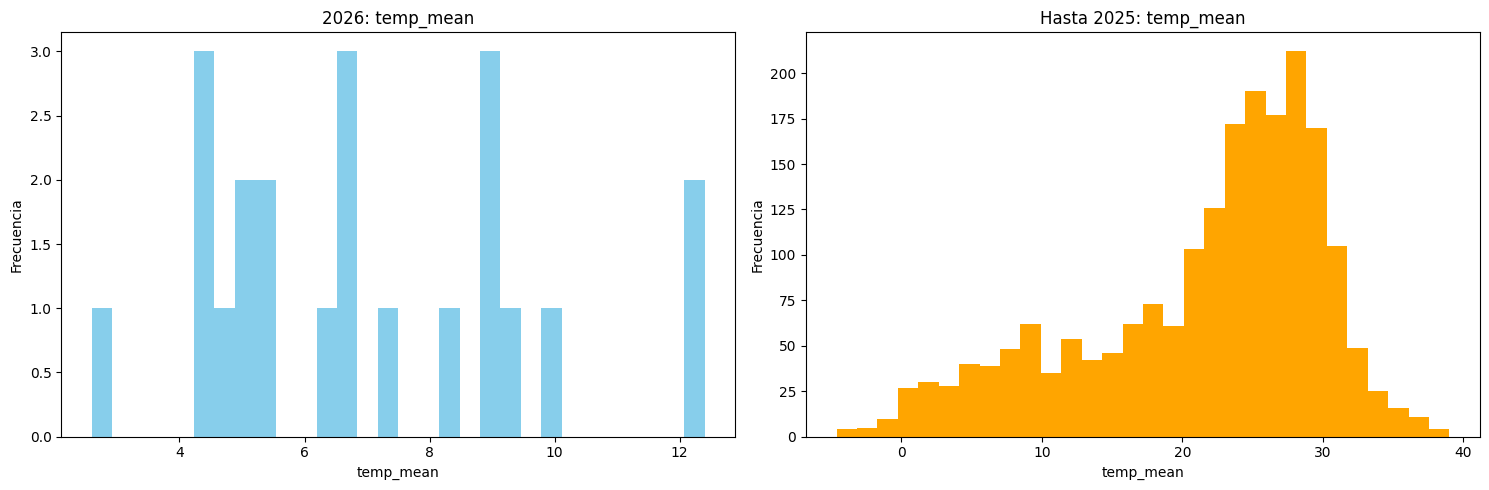

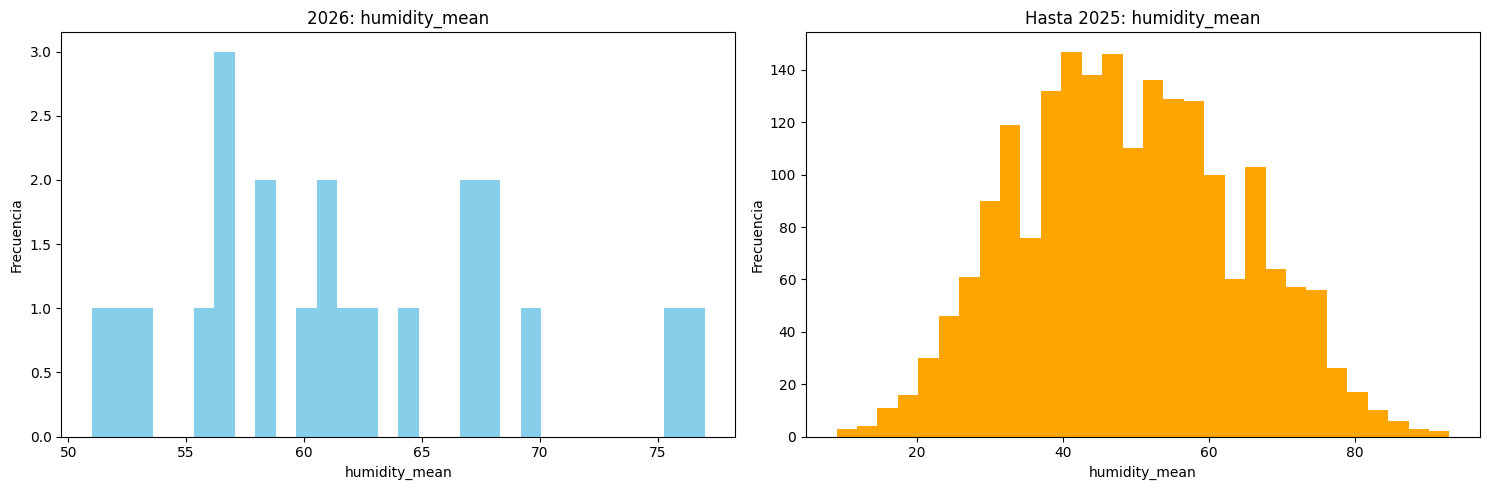

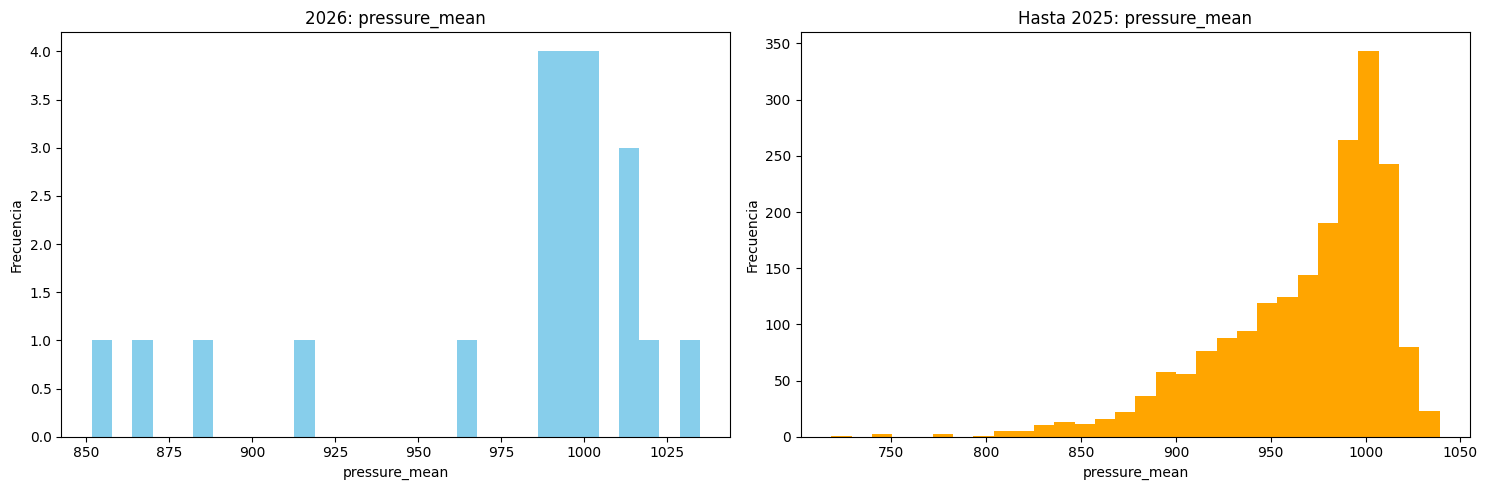

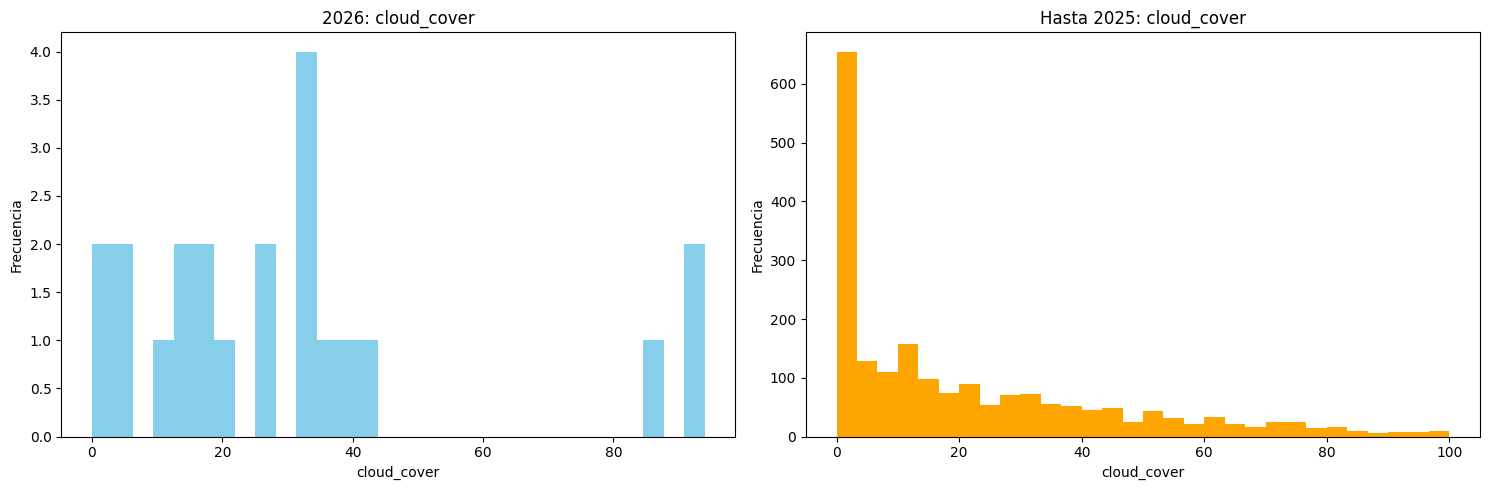

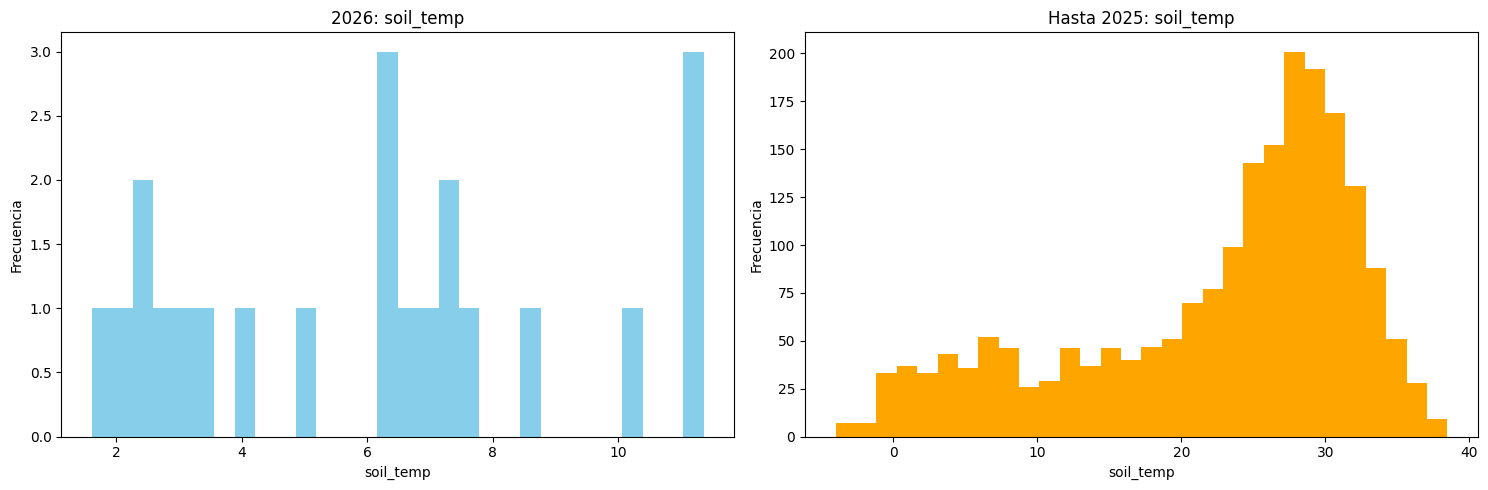

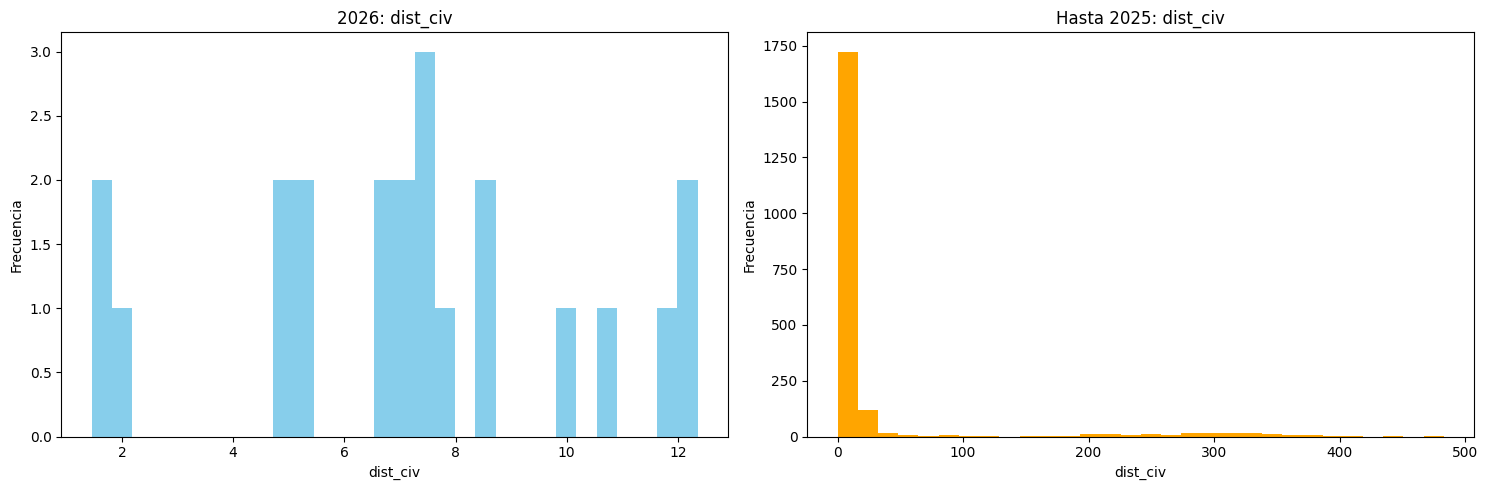

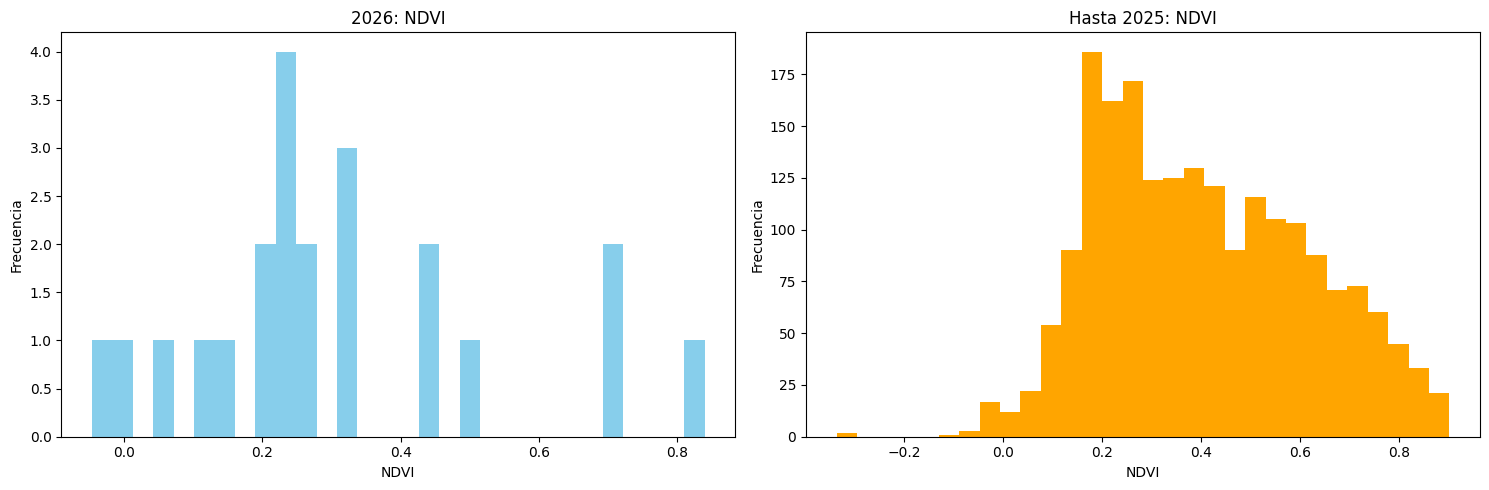

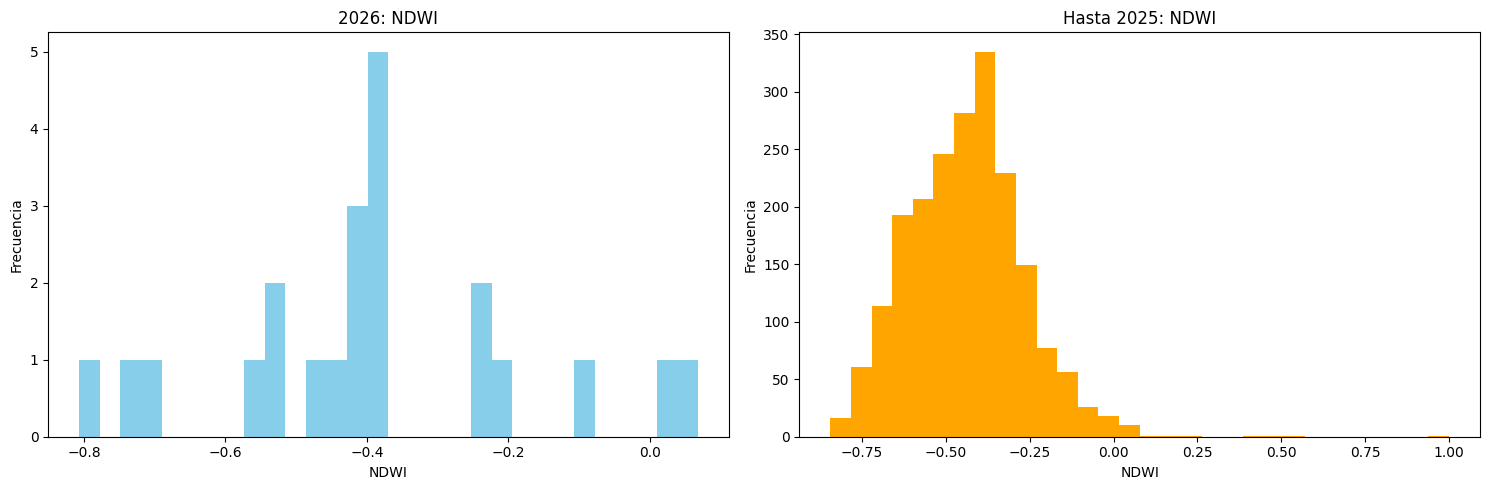

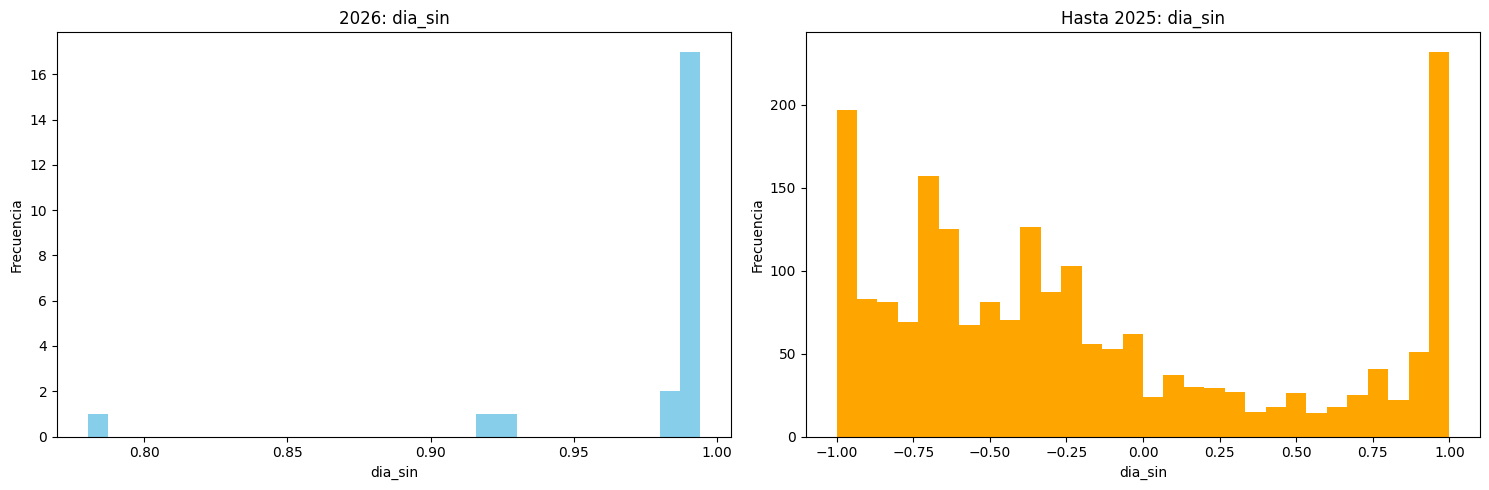

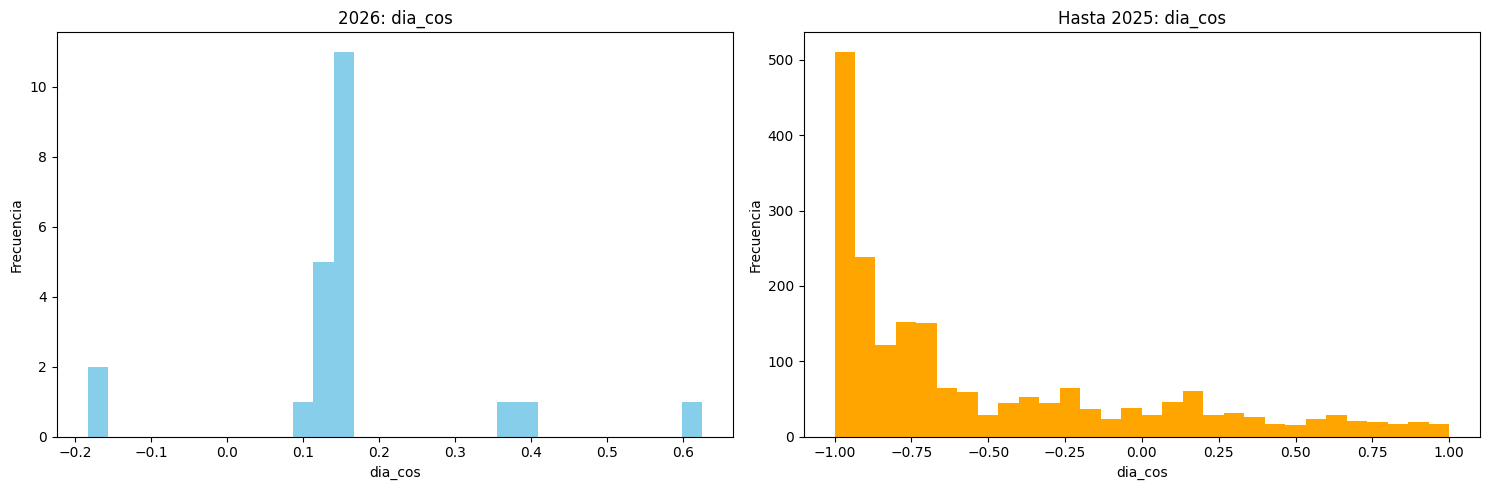

In [ ]:
columnas = df_2026.columns.drop(["date", "final"])
df_2026_incendios = df_2026[df_2026['final'] == 1]
df_2025_incendios = df_hasta_2025[df_hasta_2025['final'] == 1]

for col in columnas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfica de 2026 (Izquierda)
    df_2026_incendios[col].hist(bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title(f'2026: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(False)

    # Gráfica hasta 2025 (Derecha)
    df_2025_incendios[col].hist(bins=30, ax=axes[1], color='orange')
    axes[1].set_title(f'Hasta 2025: {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frecuencia')
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

**DISTRIBUCIÓN DE INCENDIOS POR MESES**

Se quiere evaluar la distribución de los incendios por meses, para conocer qué meses presentan un mayor riesgo de incendio.

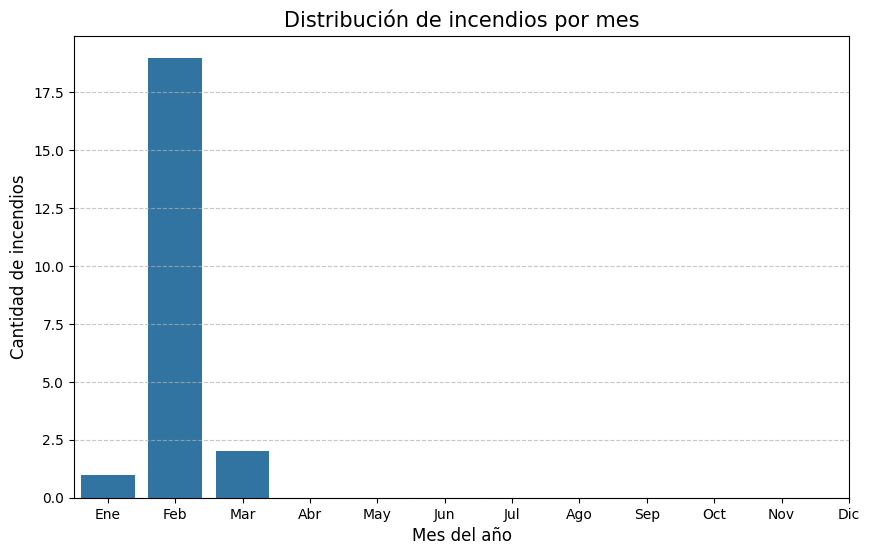

In [29]:
df_2026_incendios['month'] = df_2026_incendios['date'].dt.month
df_incendios = df_2026_incendios[df_2026_incendios['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='month')

plt.title('Distribución de incendios por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Podría concluirse que todos los incendios registrados son en febrero.

**CORRELACIÓN CON LA VARIABLE OBJETIVO**

In [31]:
df3 = df_2026.drop(columns = ['date'])
correlaciones = df3.corr()
corr_objetivo = correlaciones['final'].drop(labels=['final']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
sunshine_seconds,0.188702
radiation,0.180577
dia_sin,0.159856
temp_max,0.111974
evapotranspiration,0.101172
temp_mean,0.060718
pressure_mean,0.045769
lat,0.029451
lon,0.029420
soil_temp,0.028209


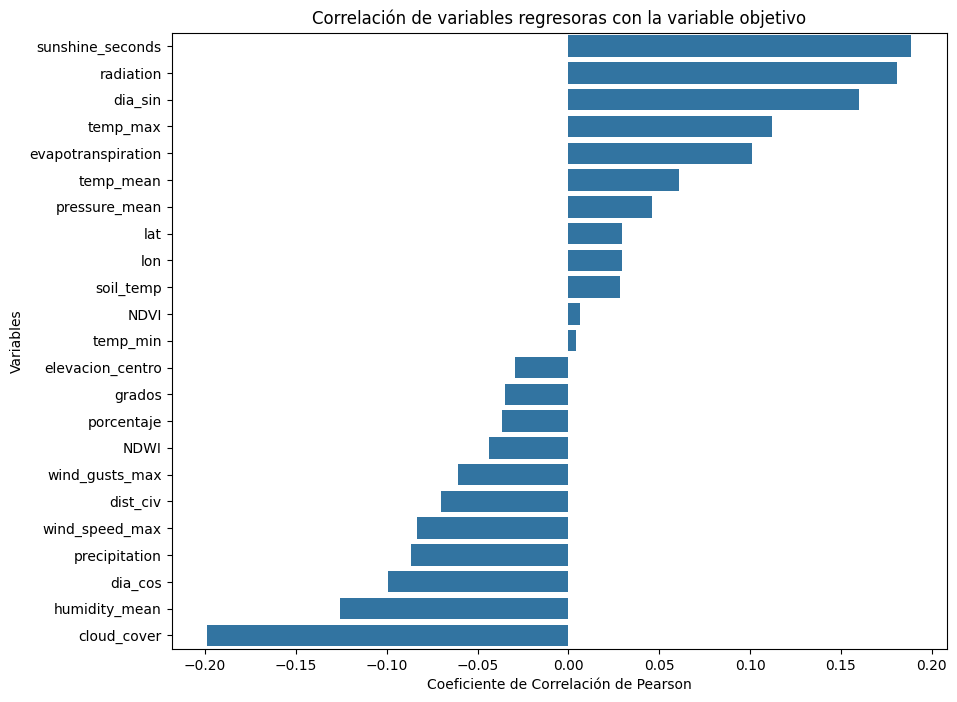

In [32]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

In [ ]:
df_hasta_2025['date'] = pd.to_datetime(df_hasta_2025['date'])
df_25 = df_hasta_2025[df_hasta_2025['date'].dt.month.isin([1, 2, 3, 4])]

print(f"Numero de incendios en 2026 de enero a abril: {len(df_2026[df_2026["final"] == 1])} incendios")
print(f"Numero de incendios en 2025 de enero a abril: {len(df_25[df_25["final"] == 1])} incendios")

Numero de incendios en 2026 de enero a abril: 22 incendios
Numero de incendios en 2025 de enero a abril: 399 incendios
